# LLM-Augmented Explainable Machine Learning for Breast Cancer pCR Prediction
### Dataset: GSE163882 | RNA-seq TPM | 222 Multi-institutional Biopsies
---

**Background:**
Pathological complete response (pCR) to neoadjuvant chemotherapy is a critical endpoint in breast cancer treatment, serving as a surrogate marker for long-term survival outcomes (Cortazar et al., 2014, *Lancet*). Accurate prediction of pCR from pre-treatment transcriptomic profiles enables personalised treatment planning and avoidance of ineffective cytotoxic regimens (Hatzis et al., 2011, *JAMA*). This pipeline implements a supervised machine learning approach to predict pCR using RNA-seq gene expression data from the GSE163882 multi-institutional cohort, integrating SHAP-based explainability (Lundberg & Lee, 2017, *NeurIPS*) and LLM-augmented biological interpretation.

**Methodological Framework:**
This pipeline follows the structured ML workflow prescribed in the course *Supervised Machine Learning Tutorial* (Tutorial 1) and *Ensemble Learning Techniques* (Tutorial 2), covering:
- Rigorous train-test splitting with stratification (*ML Lecture 2: Model Evaluation*)
- Variance-based feature filtering (*ML Lecture 3: Feature Selection*)
- SMOTE for class imbalance correction (*ML Lecture 2: Handling Imbalanced Data*)
- Cross-validation for unbiased model comparison (*Tutorial 1, Section 4*)
- SHAP values for post-hoc model interpretability (*Presentation v1: XAI Component*)

**Pipeline Overview:**
1. Environment Setup
2. Data Loading and Inspection
3. Metadata Extraction and Target Variable
4. Data Merging and Quality Check
5. Exploratory Data Analysis (EDA)
6. Preprocessing and Feature Engineering
7. Class Imbalance Assessment
8. Supervised ML Benchmarking
9. Model Evaluation and Comparison
10. SHAP Explainability Analysis
11. LLM Interpretation Layer
12. Subgroup Analysis (TNBC vs non-TNBC)
13. Summary and Results Export


## Section 1: Environment Setup

All required libraries are imported here to ensure full reproducibility. Random seeds are set globally for NumPy, scikit-learn, and XGBoost to guarantee deterministic results across runs, following best practices from the *Overfitting & Underfitting Tutorial* (Tutorial 3).


In [1]:
# Install required packages (run once)
# Uncomment if running for the first time
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap umap-learn imbalanced-learn GEOparse requests tqdm


In [2]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import re
import json
import requests
warnings.filterwarnings('ignore')

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     train_test_split, GridSearchCV)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve,
                              average_precision_score, matthews_corrcoef)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Explainability ───────────────────────────────────────────────────────────
import shap
shap.initjs()

# ── Dimensionality Reduction ─────────────────────────────────────────────────
import umap

# ── Display settings ─────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'


# ── Output directory ─────────────────────────────────────────────────────────
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("All libraries loaded successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {__import__('sklearn').__version__}")


All libraries loaded successfully.
Pandas version: 3.0.3
Scikit-learn version: 1.8.0


## Section 2: Data Loading and Inspection

Load the TPM expression matrix and series matrix metadata file. The GSE163882 dataset (Hatzis et al.) comprises RNA-seq transcriptomes from 222 breast cancer biopsies collected across multiple institutions prior to neoadjuvant chemotherapy.

**Data source:** GEO Accession [GSE163882](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE163882)


In [3]:
# ── File paths (adjust if files are in a subfolder) ─────────────────────────
TPM_FILE    = "GSE163882_all.data.tpms_222Samples.csv"
MATRIX_FILE = "GSE163882_series_matrix.txt"

# ── Load TPM expression data ─────────────────────────────────────────────────
print("Loading TPM expression matrix...")
tpm_raw = pd.read_csv(TPM_FILE, index_col=0)

# Drop non-sample columns (e.g. 'annotation')
non_sample_cols = [c for c in tpm_raw.columns if not c.startswith('BA')]
if non_sample_cols:
    print(f"Dropping non-sample columns: {non_sample_cols}")
    tpm_raw = tpm_raw.drop(columns=non_sample_cols)

print(f"TPM matrix shape (genes x samples): {tpm_raw.shape}")
print(f"First 5 gene names: {tpm_raw.index[:5].tolist()}")
print(f"First 3 sample IDs: {tpm_raw.columns[:3].tolist()}")
tpm_raw.head(3)


Loading TPM expression matrix...


Dropping non-sample columns: ['annotation']
TPM matrix shape (genes x samples): (60279, 222)
First 5 gene names: ['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419', 'ENSG00000000457', 'ENSG00000000460']
First 3 sample IDs: ['BA00129', 'BA00130', 'BA00132']


,BA00129,BA00130,BA00132,BA00133,BA00135,BA00136,BA00137,BA00138,BA00139,BA00140,BA00141,BA00142,BA00143,BA00145,BA00146,BA00147,BA00148,BA00149,BA00150,BA00151,BA00152,BA00161,BA00162,BA00163,BA00165,...,BA00638,BA00639,BA00640,BA00641,BA00643,BA00644,BA00645,BA00646,BA00647,BA00648,BA00649,BA00651,BA00653,BA00654,BA00655,BA00027,BA00063,BA00101,BA00134,BA00154,BA00164,BA00166,BA00448,BA00586,BA00636
ENSG00000000003,6.2400,12.1900,9.1900,1.2300,5.0000,4.9900,3.2900,5.2700,11.1600,7.2500,7.3300,1.6900,10.4300,26.8600,21.0300,1.5500,4.5800,8.4600,5.6400,2.1800,8.8700,4.5600,3.5700,5.4100,1.1400,...,6.6600,9.5300,2.7600,9.0300,9.7700,12.6900,5.1000,9.9200,10.8600,4.1200,12.9700,6.4500,13.5500,6.0300,7.9400,1.0200,4.4900,8.7800,8.0100,1.5400,7.8800,8.6800,7.9800,8.6900,0.0500
ENSG00000000005,0.0000,0.0000,0.4600,0.0000,0.0000,0.2700,0.0000,0.3900,0.0000,0.0300,1.2800,0.0000,0.2000,0.2000,0.0300,0.0000,0.0000,0.5000,0.2600,0.0000,0.0000,0.0100,0.0000,0.0000,0.0000,...,0.7200,0.1800,0.1100,0.0400,0.2600,0.0300,0.0400,0.4300,0.2300,0.2600,0.6700,0.1600,1.8300,2.9500,0.2000,0.0000,0.0000,0.2200,0.0000,2.7400,0.0000,0.0000,1.2800,0.3400,0.0000
ENSG00000000419,28.4100,16.7500,60.7400,0.0000,42.8800,16.3900,4.9000,14.0400,5.0300,55.1600,42.1500,1.4400,111.5200,36.0300,79.0900,3.2700,46.2400,9.7200,25.8200,6.3800,59.3700,24.6300,8.7700,15.8000,1.9000,...,41.1000,46.1900,50.0700,66.1500,48.1000,90.3600,22.1700,35.9400,50.2000,38.9400,54.2100,44.0400,101.5500,60.7100,33.3000,26.5500,30.2000,55.4900,35.2100,2.1400,31.0600,21.8800,64.8000,26.2000,1.4700


In [4]:
# ── Transpose so samples are rows and genes are columns ─────────────────────
tpm = tpm_raw.T
print(f"Transposed shape (samples x genes): {tpm.shape}")
tpm.head(3)


Transposed shape (samples x genes): (222, 60279)


,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,ENSG00000001460,ENSG00000001461,ENSG00000001497,ENSG00000001561,ENSG00000001617,ENSG00000001626,ENSG00000001629,ENSG00000001630,ENSG00000001631,ENSG00000002016,ENSG00000002079,ENSG00000002330,ENSG00000002549,ENSG00000002586,ENSG00000002587,...,ENSG00000280430,ENSG00000280431,ENSG00000280432,ENSG00000280433,ENSG00000280434,ENSG00000280435,ENSG00000280436,ENSG00000280437,ENSG00000280438,ENSG00000280439,ENSG00000280440,ENSG00000280441,ENSG00000280442,ENSG00000280443,ENSG00000280444,ENSG00000280445,ENSG00000280446,ENSG00000280447,ENSG00000280448,ENSG00000280449,ENSG00000280450,ENSG00000280451,ENSG00000280452,ENSG00000280453,ENSG00000280454
BA00129,6.2400,0.0000,28.4100,1.7800,2.7300,0.0000,4.2500,5.8100,14.3900,7.6500,3.5000,2.5600,1.1100,0.2500,1.8300,0.0100,11.6400,33.3600,0.1400,13.7100,0.1500,10.3400,117.4600,40.6900,0.0600,...,0.0000,0.0000,0.0000,0.0000,0.1000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.9800,0.0000,0.0000,0.1100,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
BA00130,12.1900,0.0000,16.7500,2.9000,1.1100,2.9400,8.5500,5.7200,38.3000,29.2400,3.4700,0.3200,0.8400,0.3700,6.0500,0.0000,9.6600,22.4600,0.5100,1.0000,0.0200,5.1400,41.2000,108.7500,0.1100,...,0.0000,0.0000,0.0000,0.0300,0.1600,0.0000,0.0000,0.0800,0.0000,0.0000,0.0000,3.5100,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
BA00132,9.1900,0.4600,60.7400,1.3200,3.7200,6.5800,32.2900,6.9500,19.3200,29.5300,15.1700,5.3500,2.6800,1.6000,2.6900,0.0200,35.3900,34.3600,0.0000,15.3600,0.0000,13.8100,101.2800,65.2900,0.2800,...,0.0000,0.0000,0.0000,0.0000,0.0200,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0100,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## Section 3: Metadata Extraction and Target Variable

Parse the GEO series matrix file to extract clinical annotations including pCR/RD treatment response labels. The series matrix format stores sample characteristics as key-value pairs that require structured parsing. pCR (pathological Complete Response) indicates complete tumour eradication after chemotherapy, while RD (Residual Disease) indicates persistent tumour tissue.


In [5]:
# ── Parse series matrix file ─────────────────────────────────────────────────
print("Parsing series matrix file...")

sample_ids    = []
char_data     = {}
sample_titles = []

with open(MATRIX_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        
        # Sample accession IDs
        if line.startswith('!Sample_geo_accession'):
            sample_ids = line.split('\t')[1:]
            sample_ids = [s.strip('"') for s in sample_ids]
        
        # Sample titles (contain BA codes for crosswalk)
        if line.startswith('!Sample_title'):
            sample_titles = line.split('\t')[1:]
            sample_titles = [s.strip('"') for s in sample_titles]
        
        # All characteristics lines
        if line.startswith('!Sample_characteristics_ch1'):
            values = line.split('\t')[1:]
            values = [v.strip('"') for v in values]
            
            # Determine field name from first non-empty value
            key = values[0].split(':')[0].strip() if ':' in values[0] else f"char_{len(char_data)}"
            parsed = []
            for v in values:
                if ':' in v:
                    parsed.append(v.split(':', 1)[1].strip())
                else:
                    parsed.append(v.strip())
            char_data[key] = parsed

print(f"Found {len(sample_ids)} samples")
print(f"Characteristics fields found: {list(char_data.keys())}")
print(f"Sample titles (first 3): {sample_titles[:3]}")


Parsing series matrix file...
Found 222 samples
Characteristics fields found: ['response to nac', 'age', 'estrogen receptor status', 'progesterone receptor status', 'her2 receptor status', 'tumor grage', 'breast cancer stage', 'tissue']
Sample titles (first 3): ['BA00111: WT169901238(A1)', 'BA00568: CS16-10701', 'BA00116: WT169912674(A1)']


In [6]:
# ── Build metadata dataframe ─────────────────────────────────────────────────
meta = pd.DataFrame(char_data, index=sample_ids)
print(f"Metadata shape: {meta.shape}")
print("\nAll metadata columns:")
for col in meta.columns:
    print(f"  '{col}': {meta[col].unique()[:5]}")
meta.head()


Metadata shape: (222, 8)

All metadata columns:
  'response to nac': <StringArray>
['pCR', 'RD']
Length: 2, dtype: str
  'age': <StringArray>
['65', '51', '59', '56', '45']
Length: 5, dtype: str
  'estrogen receptor status': <StringArray>
['N', 'P']
Length: 2, dtype: str
  'progesterone receptor status': <StringArray>
['N', 'P']
Length: 2, dtype: str
  'her2 receptor status': <StringArray>
['N', 'P']
Length: 2, dtype: str
  'tumor grage': <StringArray>
['3', '2', '1', '0']
Length: 4, dtype: str
  'breast cancer stage': <StringArray>
['NA', '1', '2', '3', '4']
Length: 5, dtype: str
  'tissue': <StringArray>
['breast cancer']
Length: 1, dtype: str


,response to nac,age,estrogen receptor status,progesterone receptor status,her2 receptor status,tumor grage,breast cancer stage,tissue
GSM4989073,pCR,65,N,N,N,3,NA,breast cancer
GSM4989074,pCR,51,N,N,P,3,NA,breast cancer
GSM4989075,pCR,59,N,N,P,2,NA,breast cancer
GSM4989076,pCR,56,N,N,P,3,NA,breast cancer
GSM4989077,pCR,45,P,P,P,3,NA,breast cancer


In [7]:
# ── Extract pCR/RD target label ──────────────────────────────────────────────
# Identify which column contains pCR/RD information
# Look for the column containing 'pCR' or 'RD' or 'response'
target_col = None
for col in meta.columns:
    unique_vals = meta[col].str.lower().unique()
    if any('pcr' in str(v) or 'residual' in str(v) or 
           ' rd' in str(v) or 'response' in str(v) 
           for v in unique_vals):
        target_col = col
        print(f"Target column found: '{col}'")
        print(f"Unique values: {meta[col].unique()}")
        break

if target_col is None:
    print("\nCould not auto-detect. Printing all unique values per column:")
    for col in meta.columns:
        print(f"  {col}: {meta[col].unique()}")


Target column found: 'response to nac'
Unique values: <StringArray>
['pCR', 'RD']
Length: 2, dtype: str


In [8]:
# ── Standardise label to pCR / RD ────────────────────────────────────────────
# Adjust 'target_col' below if the auto-detection above found a different name
# Common values seen: 'pCR', 'PCR', 'RD', 'residual disease'

meta['label'] = meta[target_col].str.strip()

# Normalise to consistent labels
meta['label'] = meta['label'].replace({
    'PCR': 'pCR', 'pcr': 'pCR',
    'Residual Disease': 'RD', 'residual disease': 'RD',
    'RD ': 'RD', 'pCR ': 'pCR'
})

print("Label distribution:")
print(meta['label'].value_counts())
print(f"\nTotal samples with labels: {meta['label'].notna().sum()}")


Label distribution:
label
RD     142
pCR     80
Name: count, dtype: int64

Total samples with labels: 222


In [9]:
# ── Extract additional clinical variables if available ───────────────────────
# Subtype (TNBC vs non-TNBC)
for col in meta.columns:
    if any('tnbc' in str(v).lower() or 'triple' in str(v).lower() 
           or 'subtype' in str(v).lower() or 'her2' in str(v).lower()
           for v in meta[col].unique()):
        meta['subtype'] = meta[col].str.strip()
        print(f"Subtype column: '{col}'")
        print(meta['subtype'].value_counts())
        break

meta.head()


,response to nac,age,estrogen receptor status,progesterone receptor status,her2 receptor status,tumor grage,breast cancer stage,tissue,label
GSM4989073,pCR,65,N,N,N,3,NA,breast cancer,pCR
GSM4989074,pCR,51,N,N,P,3,NA,breast cancer,pCR
GSM4989075,pCR,59,N,N,P,2,NA,breast cancer,pCR
GSM4989076,pCR,56,N,N,P,3,NA,breast cancer,pCR
GSM4989077,pCR,45,P,P,P,3,NA,breast cancer,pCR


## Section 4: Data Merging and Quality Check

Merge the TPM expression matrix with clinical metadata using sample IDs as the join key. This step performs the critical BA-code to GSM-ID crosswalk between the expression matrix (which uses internal BA identifiers) and the metadata (which uses GEO GSM accession numbers). Data quality checks include missing value detection and duplicate sample identification.


In [10]:
# ── Align sample IDs via BA-code crosswalk ──────────────────────────────────
# TPM matrix uses BA codes (e.g., BA00129) while metadata uses GSM accessions
# (e.g., GSM4989073). The BA code is embedded in the Sample_title field.

print(f"TPM sample IDs (first 3):  {tpm.index[:3].tolist()}")
print(f"Meta sample IDs (first 3): {meta.index[:3].tolist()}")

# Build BA-code → GSM mapping from sample titles
ba_to_gsm = {}
for gsm, title in zip(sample_ids, sample_titles):
    ba_code = title.split(':')[0].strip()
    ba_to_gsm[ba_code] = gsm

print(f"\nBA-to-GSM mappings built: {len(ba_to_gsm)}")
print(f"Example: {list(ba_to_gsm.items())[:3]}")

# Map TPM BA codes to GSM IDs
tpm.index = tpm.index.map(lambda x: ba_to_gsm.get(x, x))

# Find common samples
common_samples = tpm.index.intersection(meta.index)
unmapped = [x for x in tpm.index if x.startswith('BA')]  # still BA = unmapped

print(f"\nCommon samples after crosswalk: {len(common_samples)}")
print(f"Unmapped TPM samples: {len(unmapped)}")
print(f"Only in meta: {len(meta.index.difference(tpm.index))}")


TPM sample IDs (first 3):  ['BA00129', 'BA00130', 'BA00132']
Meta sample IDs (first 3): ['GSM4989073', 'GSM4989074', 'GSM4989075']

BA-to-GSM mappings built: 222
Example: [('BA00111', 'GSM4989073'), ('BA00568', 'GSM4989074'), ('BA00116', 'GSM4989075')]

Common samples after crosswalk: 222
Unmapped TPM samples: 0
Only in meta: 0


In [11]:
# ── Merge on common samples ──────────────────────────────────────────────────
tpm_aligned  = tpm.loc[common_samples]
meta_aligned = meta.loc[common_samples]

# Combine into one dataframe
data = tpm_aligned.copy()
data['label']   = meta_aligned['label']
if 'subtype' in meta_aligned.columns:
    data['subtype'] = meta_aligned['subtype']

# Remove samples with missing labels
data = data.dropna(subset=['label'])
print(f"Final dataset shape: {data.shape}")
print(f"\nLabel counts:")
print(data['label'].value_counts())

# Encode labels: pCR = 1, RD = 0
le = LabelEncoder()
data['label_enc'] = le.fit_transform(data['label'])
print(f"\nEncoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Final dataset shape: (222, 60280)

Label counts:
label
RD     142
pCR     80
Name: count, dtype: int64



Encoding: {'RD': np.int64(0), 'pCR': np.int64(1)}


In [12]:
# ── Basic data quality check ─────────────────────────────────────────────────
print("=== Data Quality Report ===")
print(f"Total samples:       {data.shape[0]}")
gene_cols = [c for c in data.columns if c not in ['label', 'label_enc', 'subtype']]
print(f"Total gene features: {len(gene_cols)}")
print(f"Missing values:      {data.isnull().sum().sum()}")
print(f"Duplicate samples:   {data.index.duplicated().sum()}")

if data.shape[0] > 0:
    tpm_stats = data[gene_cols].values.flatten()
    print(f"\nTPM value statistics:")
    print(f"  Min:    {tpm_stats.min():.3f}")
    print(f"  Mean:   {tpm_stats.mean():.3f}")
    print(f"  Median: {np.median(tpm_stats):.3f}")
    print(f"  Max:    {tpm_stats.max():.3f}")
else:
    print("\n⚠️ WARNING: No samples in merged dataset. Check crosswalk.")


=== Data Quality Report ===
Total samples:       222


Total gene features: 60279


Missing values:      0
Duplicate samples:   0



TPM value statistics:
  Min:    0.000
  Mean:   16.590
  Median: 0.000
  Max:    326199.540


## Section 5: Exploratory Data Analysis (EDA)

Comprehensive visualisation of data structure, class distribution, expression patterns, and sample-level relationships. EDA is essential before model building to identify potential confounders, batch effects, and data quality issues (*ML Lecture 1: Data Understanding*; *PCA Tutorial*, Tutorial 4).

**Techniques applied:**
- Class distribution analysis to quantify label imbalance
- TPM distribution before/after log2 transformation
- PCA for linear dimensionality reduction and variance decomposition (*PCA Tutorial*)
- UMAP for non-linear manifold learning (McInnes et al., 2018, *JMLR*)
- Heatmap of top variable genes to assess expression heterogeneity


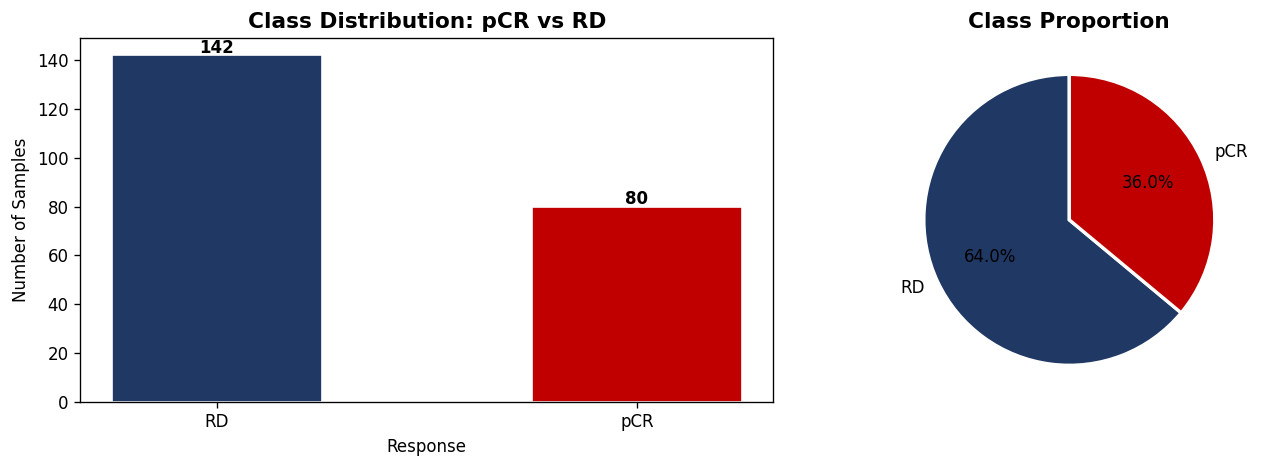

Class imbalance ratio: 1.77:1


In [13]:
# ── 5.1 Class distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = data['label'].value_counts()
colors = ['#1F3864', '#C00000']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution: pCR vs RD', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xlabel('Response')
for i, (idx, val) in enumerate(counts.items()):
    axes[0].text(i, val + 1, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'class_distribution.png'), bbox_inches='tight')
plt.show()
print(f"Class imbalance ratio: {counts.max()/counts.min():.2f}:1")


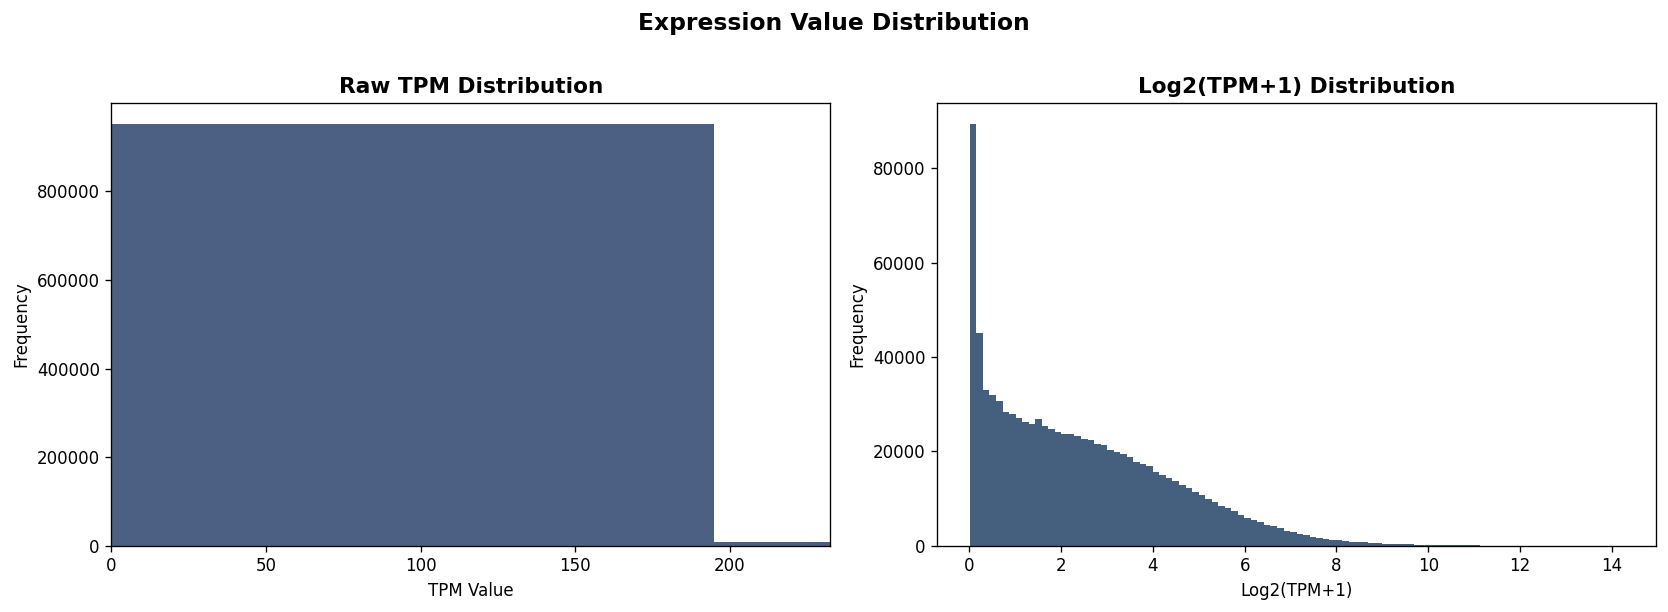

In [14]:
# ── 5.2 TPM distribution before and after log transformation ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Select a subset of genes for speed
sample_genes = gene_cols[:5000]
tpm_vals     = data[sample_genes].values.flatten()
tpm_vals     = tpm_vals[tpm_vals > 0]  # remove zeros for log

axes[0].hist(tpm_vals, bins=100, color='#1F3864', alpha=0.8, edgecolor='none')
axes[0].set_title('Raw TPM Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('TPM Value')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim([0, np.percentile(tpm_vals, 99)])

log_vals = np.log2(tpm_vals + 1)
axes[1].hist(log_vals, bins=100, color='#17375E', alpha=0.8, edgecolor='none')
axes[1].set_title('Log2(TPM+1) Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log2(TPM+1)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Expression Value Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'tpm_distribution.png'), bbox_inches='tight')
plt.show()


Running PCA...


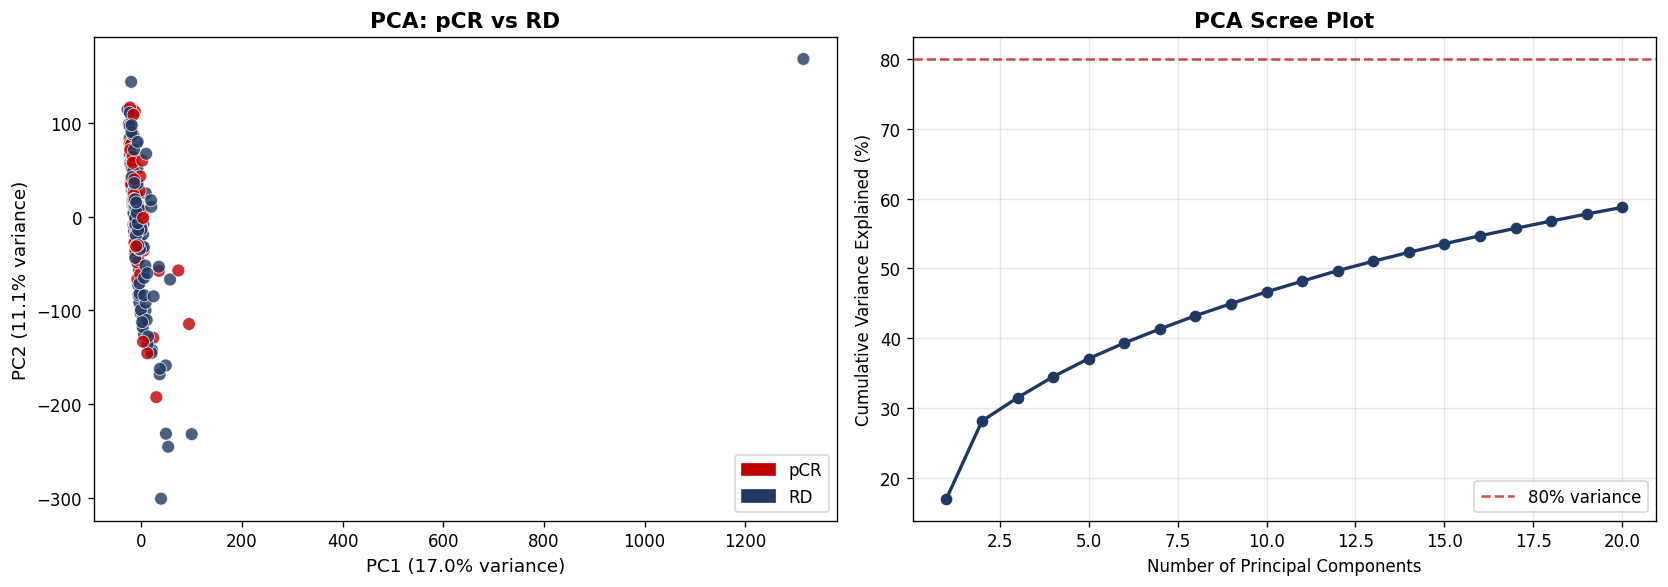

PCs needed for 80% variance: 1


In [15]:
# ── 5.3 PCA Visualisation ────────────────────────────────────────────────────
print("Running PCA...")
X_raw = data[gene_cols].values
y     = data['label_enc'].values

# Log transform first
X_log = np.log2(X_raw + 1)

# Standardise
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# PCA
pca     = PCA(n_components=50, random_state=42)
X_pca   = pca.fit_transform(X_scaled)

# Variance explained
var_exp = pca.explained_variance_ratio_
cum_var = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter
colors_map = {0: '#1F3864', 1: '#C00000'}
color_list = [colors_map[l] for l in y]
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=color_list, alpha=0.8, s=60, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)', fontsize=11)
axes[0].set_title('PCA: pCR vs RD', fontsize=13, fontweight='bold')
patches = [mpatches.Patch(color='#C00000', label='pCR'),
           mpatches.Patch(color='#1F3864', label='RD')]
axes[0].legend(handles=patches)

# Scree plot
axes[1].plot(range(1, 21), cum_var[:20]*100, 'o-', color='#1F3864', linewidth=2)
axes[1].axhline(y=80, color='#C00000', linestyle='--', alpha=0.7, label='80% variance')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('PCA Scree Plot', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'pca_analysis.png'), bbox_inches='tight')
plt.show()
print(f"PCs needed for 80% variance: {np.argmax(cum_var >= 0.80) + 1}")


Running UMAP (this may take 1-2 minutes)...


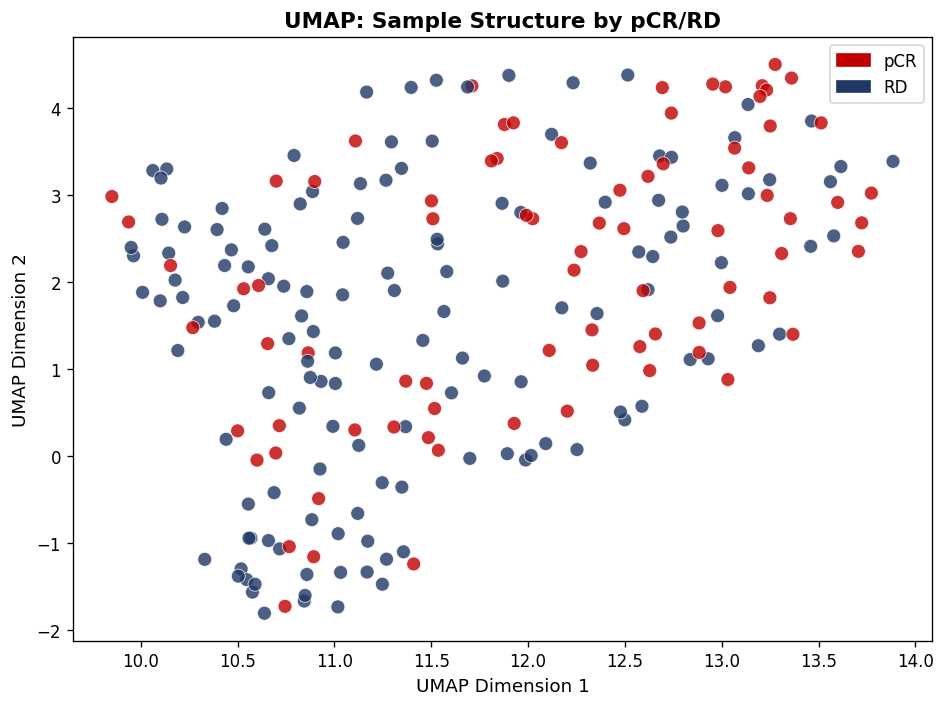

In [16]:
# ── 5.4 UMAP Visualisation ───────────────────────────────────────────────────
print("Running UMAP (this may take 1-2 minutes)...")
reducer  = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap   = reducer.fit_transform(X_scaled)

fig, ax  = plt.subplots(figsize=(8, 6))
scatter  = ax.scatter(X_umap[:, 0], X_umap[:, 1],
                      c=color_list, alpha=0.8, s=70,
                      edgecolors='white', linewidth=0.5)
ax.set_xlabel('UMAP Dimension 1', fontsize=11)
ax.set_ylabel('UMAP Dimension 2', fontsize=11)
ax.set_title('UMAP: Sample Structure by pCR/RD', fontsize=13, fontweight='bold')
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'umap_analysis.png'), bbox_inches='tight')
plt.show()


Generating expression heatmap for top variable genes...


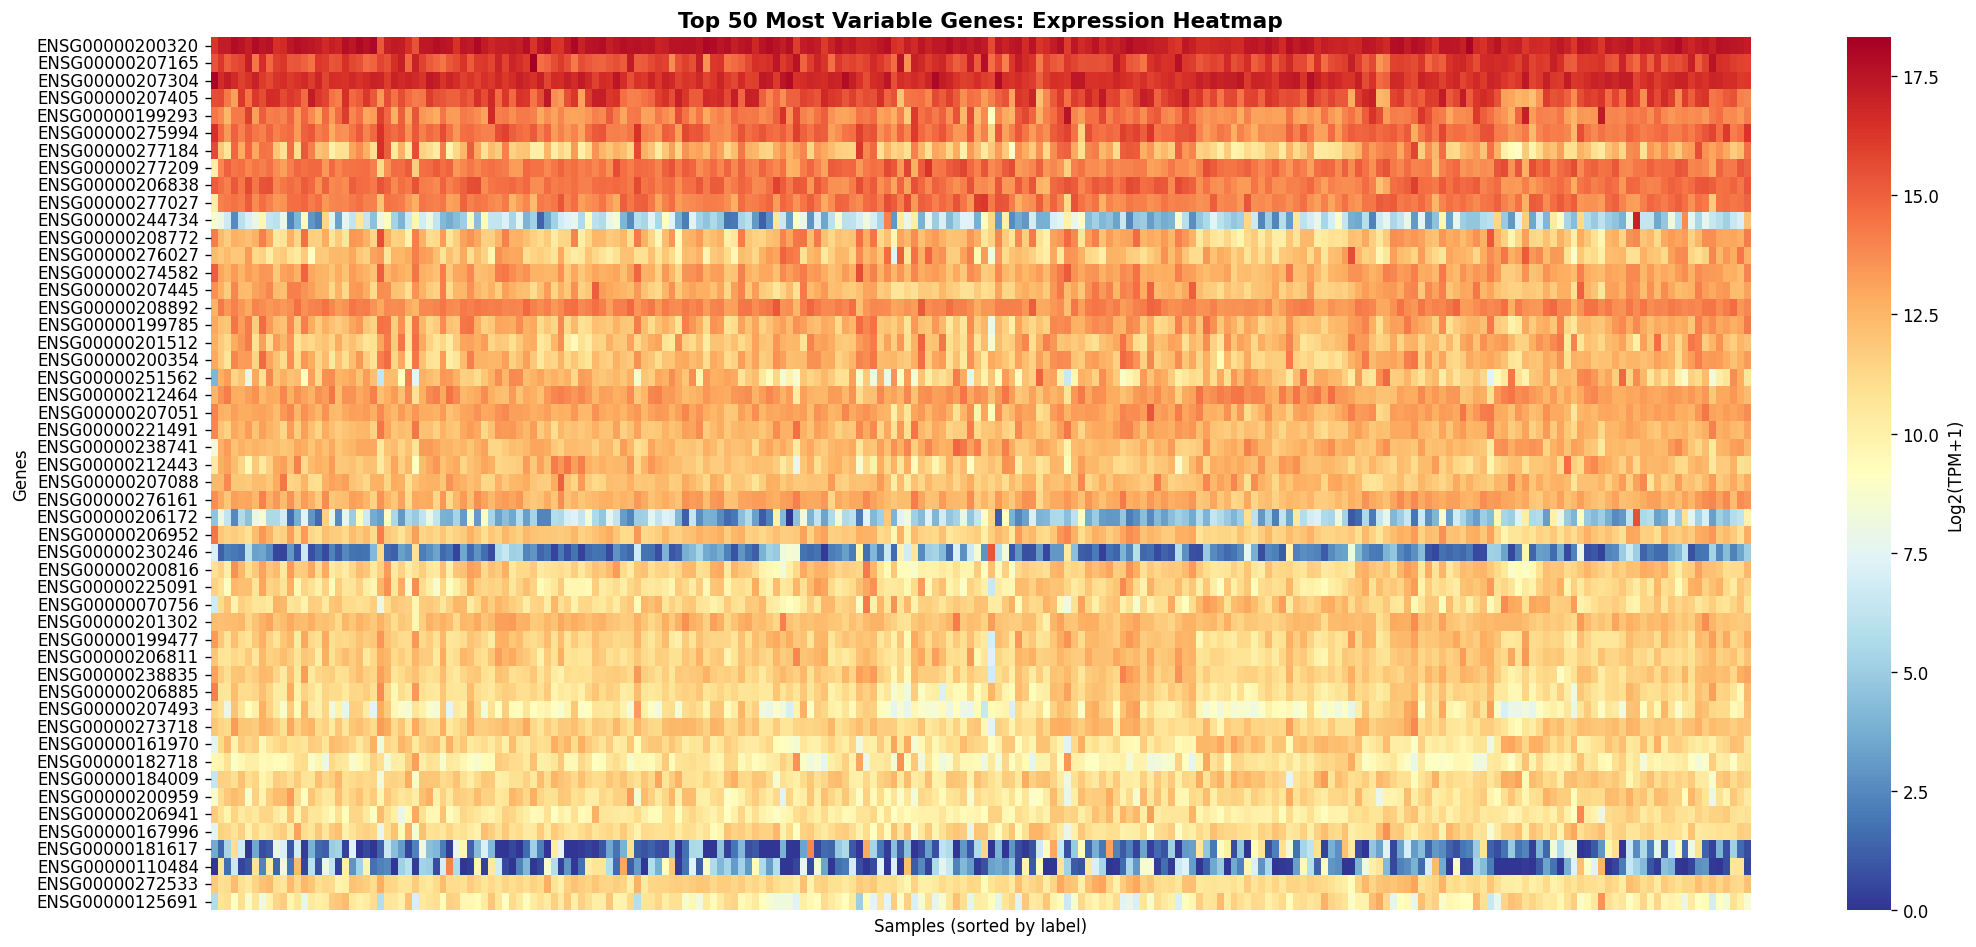

In [17]:
# ── 5.5 Top variable genes heatmap ──────────────────────────────────────────
print("Generating expression heatmap for top variable genes...")

# Select top 50 most variable genes
gene_var   = data[gene_cols].var().sort_values(ascending=False)
top50_genes = gene_var.head(50).index.tolist()

hmap_data  = np.log2(data[top50_genes].values + 1)
hmap_df    = pd.DataFrame(hmap_data, index=data['label'], columns=top50_genes)
hmap_sorted = hmap_df.sort_index()

fig, ax    = plt.subplots(figsize=(18, 8))
row_colors = hmap_sorted.index.map({'pCR': '#C00000', 'RD': '#1F3864'})
sns.heatmap(hmap_sorted.T, cmap='RdYlBu_r', ax=ax,
            xticklabels=False, yticklabels=True,
            cbar_kws={'label': 'Log2(TPM+1)'},
            linewidths=0, rasterized=True)
ax.set_title('Top 50 Most Variable Genes: Expression Heatmap', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Samples (sorted by label)')
ax.set_ylabel('Genes')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'heatmap_top50.png'), bbox_inches='tight')
plt.show()


## Section 6: Preprocessing and Feature Engineering

Apply standard RNA-seq preprocessing steps following established bioinformatics best practices:

1. **Log2(TPM+1) transformation**: Stabilises variance and normalises the highly skewed TPM distribution (Conesa et al., 2016, *Genome Biology*)
2. **Variance filtering** (threshold=0.1): Removes near-zero-variance genes that contribute noise but no discriminative signal (*ML Lecture 3: Feature Selection*)
3. **Stratified 80/20 train-test split**: Preserves class proportions in both splits (*Tutorial 1, Section 3.2*)
4. **StandardScaler**: Z-score normalisation fitted on training data only to prevent data leakage (*ML Lecture 2: Avoiding Data Leakage*; *Overfitting Tutorial*)


In [18]:
# ── 6.1 Log2 transformation ──────────────────────────────────────────────────
X_log = np.log2(data[gene_cols].values + 1)
y     = data['label_enc'].values
labels = data['label'].values

print(f"Features before filtering: {X_log.shape[1]}")

# ── 6.2 Remove near-zero variance genes ──────────────────────────────────────
from sklearn.feature_selection import VarianceThreshold
vt      = VarianceThreshold(threshold=0.1)
X_filt  = vt.fit_transform(X_log)
kept_genes = [gene_cols[i] for i in range(len(gene_cols)) if vt.get_support()[i]]

print(f"Features after variance filtering: {X_filt.shape[1]}")
print(f"Genes removed: {X_log.shape[1] - X_filt.shape[1]}")


Features before filtering: 60279


Features after variance filtering: 16418
Genes removed: 43861


In [19]:
# ── 6.3 Stratified train-test split (80/20) ──────────────────────────────────
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_filt, y, np.arange(len(y)),
    test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining label distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test label distribution:     {dict(zip(*np.unique(y_test, return_counts=True)))}")


Training set: 177 samples
Test set:     45 samples

Training label distribution: {np.int64(0): np.int64(113), np.int64(1): np.int64(64)}
Test label distribution:     {np.int64(0): np.int64(29), np.int64(1): np.int64(16)}


In [20]:
# ── 6.4 Standardise features ─────────────────────────────────────────────────
scaler   = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_sc  = scaler.transform(X_test)         # apply same scale to test

print("Standardisation complete.")
print(f"Train mean (should be ~0): {X_train_sc.mean():.4f}")
print(f"Train std  (should be ~1): {X_train_sc.std():.4f}")


Standardisation complete.


Train mean (should be ~0): -0.0000
Train std  (should be ~1): 0.9983


## Section 7: Class Imbalance Assessment and SMOTE

Assess and correct the imbalance between pCR and RD classes using Synthetic Minority Over-sampling Technique (SMOTE) (Chawla et al., 2002, *JAIR*). SMOTE generates synthetic minority-class samples by interpolating between existing minority neighbours.

**Critical implementation detail:** SMOTE is applied **only to the training set** to prevent information leakage into the test set (*ML Lecture 2: Handling Imbalanced Data*; *Tutorial 1, Section 5*). The test set remains untouched to provide an unbiased estimate of generalisation performance.


In [21]:
# ── 7.1 Visualise imbalance ──────────────────────────────────────────────────
unique, counts_train = np.unique(y_train, return_counts=True)
print(f"Before SMOTE - Training set:")
print(f"  RD  (0): {counts_train[0]}")
print(f"  pCR (1): {counts_train[1]}")
print(f"  Ratio:   {counts_train[0]/counts_train[1]:.2f}:1")


Before SMOTE - Training set:
  RD  (0): 113
  pCR (1): 64
  Ratio:   1.77:1


After SMOTE - Training set:
  RD  (0): 113
  pCR (1): 113
  Ratio:   1.00:1

Test set remains untouched: 45 samples


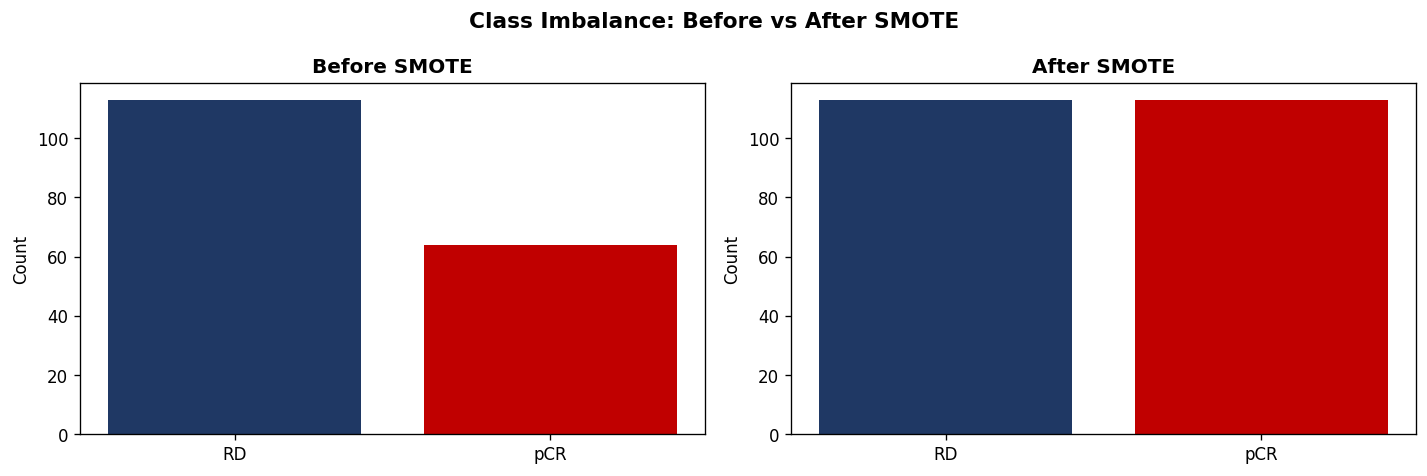

In [22]:
# ── 7.2 Apply SMOTE to training set ONLY ─────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

unique_sm, counts_sm = np.unique(y_train_sm, return_counts=True)
print(f"After SMOTE - Training set:")
print(f"  RD  (0): {counts_sm[0]}")
print(f"  pCR (1): {counts_sm[1]}")
print(f"  Ratio:   {counts_sm[0]/counts_sm[1]:.2f}:1")
print(f"\nTest set remains untouched: {len(y_test)} samples")

# Visualise before/after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['RD', 'pCR'], counts_train, color=['#1F3864', '#C00000'])
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].bar(['RD', 'pCR'], counts_sm, color=['#1F3864', '#C00000'])
axes[1].set_title('After SMOTE', fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Class Imbalance: Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'smote_comparison.png'), bbox_inches='tight')
plt.show()


## Section 8: Supervised ML Benchmarking

Train and cross-validate three complementary classifiers, each chosen for specific strengths (*Tutorial 1: Supervised ML*; *Tutorial 2: Ensemble Learning*):

1. **Logistic Regression**: Linear baseline with L2 regularisation; interpretable coefficients (*Tutorial 1, Section 4*)
2. **Random Forest**: Bagging ensemble of decision trees; robust to overfitting in high-dimensional settings (Breiman, 2001, *Machine Learning*)
3. **XGBoost**: Gradient boosting with regularisation; state-of-the-art for tabular data (Chen & Guestrin, 2016, *KDD*)

5-fold stratified cross-validation is used to obtain robust performance estimates while preserving class proportions (*ML Lecture 2: K-Fold CV*; *Overfitting Tutorial*).


In [23]:
# ── 8.1 Define models ────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=500, max_depth=None, random_state=42,
        class_weight='balanced', n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=counts_train[0]/counts_train[1],
        random_state=42, eval_metric='logloss', verbosity=0
    ),
    'Stacking': StackingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
            ('knn', KNeighborsClassifier(n_neighbors=5)),
            ('svc', SVC(probability=True, kernel='rbf', random_state=42))
        ],
        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        cv=5,
        n_jobs=-1,
        passthrough=False
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Models defined (including Stacking ensemble). Running 5-fold cross-validation...")


Models defined (including Stacking ensemble). Running 5-fold cross-validation...


In [24]:
# ── 8.2 Cross-validation (WITHOUT SMOTE) ────────────────────────────────────
results_no_smote = {}

for name, model in models.items():
    print(f"  Training {name}...")
    auc_scores = cross_val_score(model, X_train_sc, y_train,
                                  cv=cv, scoring='roc_auc', n_jobs=-1)
    f1_scores  = cross_val_score(model, X_train_sc, y_train,
                                  cv=cv, scoring='f1', n_jobs=-1)
    results_no_smote[name] = {
        'AUC Mean':  auc_scores.mean(),
        'AUC Std':   auc_scores.std(),
        'F1 Mean':   f1_scores.mean(),
        'F1 Std':    f1_scores.std()
    }

df_no_smote = pd.DataFrame(results_no_smote).T.round(4)
print("\n5-Fold CV Results (WITHOUT SMOTE):")
print(df_no_smote)


  Training Logistic Regression...


  Training Random Forest...


  Training XGBoost...


  Training Stacking...



5-Fold CV Results (WITHOUT SMOTE):
                     AUC Mean  AUC Std  F1 Mean  F1 Std
Logistic Regression    0.6886   0.0745   0.5397  0.1418
Random Forest          0.7041   0.0524   0.4222  0.1678
XGBoost                0.7182   0.1042   0.5157  0.1033
Stacking               0.6864   0.0957   0.3884  0.2161


In [25]:
# ── 8.3 Cross-validation (WITH SMOTE) ───────────────────────────────────────
results_smote = {}

for name, model in models.items():
    print(f"  Training {name} with SMOTE...")
    auc_scores = cross_val_score(model, X_train_sm, y_train_sm,
                                  cv=cv, scoring='roc_auc', n_jobs=-1)
    f1_scores  = cross_val_score(model, X_train_sm, y_train_sm,
                                  cv=cv, scoring='f1', n_jobs=-1)
    results_smote[name] = {
        'AUC Mean':  auc_scores.mean(),
        'AUC Std':   auc_scores.std(),
        'F1 Mean':   f1_scores.mean(),
        'F1 Std':    f1_scores.std()
    }

df_smote = pd.DataFrame(results_smote).T.round(4)
print("\n5-Fold CV Results (WITH SMOTE):")
print(df_smote)


  Training Logistic Regression with SMOTE...


  Training Random Forest with SMOTE...


  Training XGBoost with SMOTE...


  Training Stacking with SMOTE...



5-Fold CV Results (WITH SMOTE):
                     AUC Mean  AUC Std  F1 Mean  F1 Std
Logistic Regression    0.8464   0.0426   0.7756  0.0733
Random Forest          0.8721   0.0597   0.7809  0.0402
XGBoost                0.8767   0.0550   0.7889  0.0747
Stacking               0.8688   0.0703   0.7683  0.0532


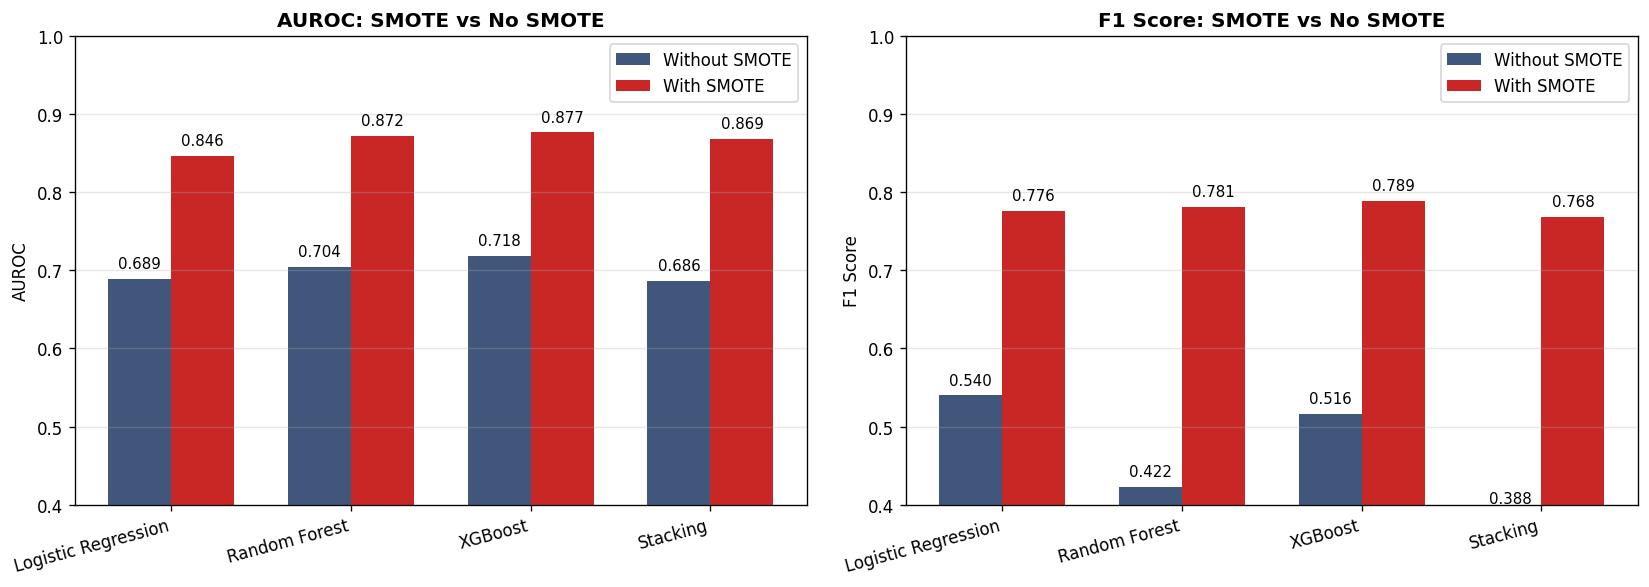

In [26]:
# ── 8.4 Compare SMOTE vs No SMOTE visually ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x         = np.arange(len(models))
width     = 0.35

for ax, metric, title in zip(axes,
                              ['AUC Mean', 'F1 Mean'],
                              ['AUROC', 'F1 Score']):
    no_sm = [results_no_smote[m][metric] for m in models]
    sm    = [results_smote[m][metric]    for m in models]
    
    bars1 = ax.bar(x - width/2, no_sm, width, label='Without SMOTE',
                   color='#1F3864', alpha=0.85)
    bars2 = ax.bar(x + width/2, sm,    width, label='With SMOTE',
                   color='#C00000', alpha=0.85)
    
    ax.set_xticks(x)
    ax.set_xticklabels(list(models.keys()), rotation=15, ha='right')
    ax.set_title(f'{title}: SMOTE vs No SMOTE', fontweight='bold')
    ax.set_ylabel(title)
    ax.set_ylim([0.4, 1.0])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'model_comparison.png'), bbox_inches='tight')
plt.show()


## Section 9: Model Evaluation on Held-Out Test Set

Evaluate all models on the 20% held-out test set using comprehensive metrics (*ML Lecture 2: Performance Metrics*):

- **AUROC**: Area Under ROC Curve — threshold-independent discrimination ability
- **AUPRC**: Area Under Precision-Recall Curve — particularly informative for imbalanced data (Saito & Rehmsmeier, 2015)
- **F1 Score**: Harmonic mean of precision and recall
- **Accuracy**: Overall correct classification rate
- **MCC**: Matthews Correlation Coefficient — balanced metric even with class imbalance (Chicco & Jurman, 2020, *BMC Genomics*)


In [27]:
# ── 9.1 Train final models and evaluate on test set ──────────────────────────
test_results = {}
trained_models = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    
    # Train on full SMOTE training set
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model
    
    # Predict on original (non-SMOTE) test set
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    
    test_results[name] = {
        'AUROC':    round(roc_auc_score(y_test, y_proba), 4),
        'AUPRC':    round(average_precision_score(y_test, y_proba), 4),
        'F1':       round(f1_score(y_test, y_pred), 4),
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'MCC':      round(matthews_corrcoef(y_test, y_pred), 4),
    }

df_test = pd.DataFrame(test_results).T
print("\n=== Test Set Performance ===")
print(df_test)


Evaluating Logistic Regression...


Evaluating Random Forest...


Evaluating XGBoost...


Evaluating Stacking...



=== Test Set Performance ===
                     AUROC  AUPRC     F1  Accuracy    MCC
Logistic Regression 0.7134 0.5927 0.5294    0.6444 0.2464
Random Forest       0.6466 0.5342 0.4000    0.6667 0.2089
XGBoost             0.6638 0.5768 0.5333    0.6889 0.3031
Stacking            0.7392 0.6483 0.3704    0.6222 0.1176


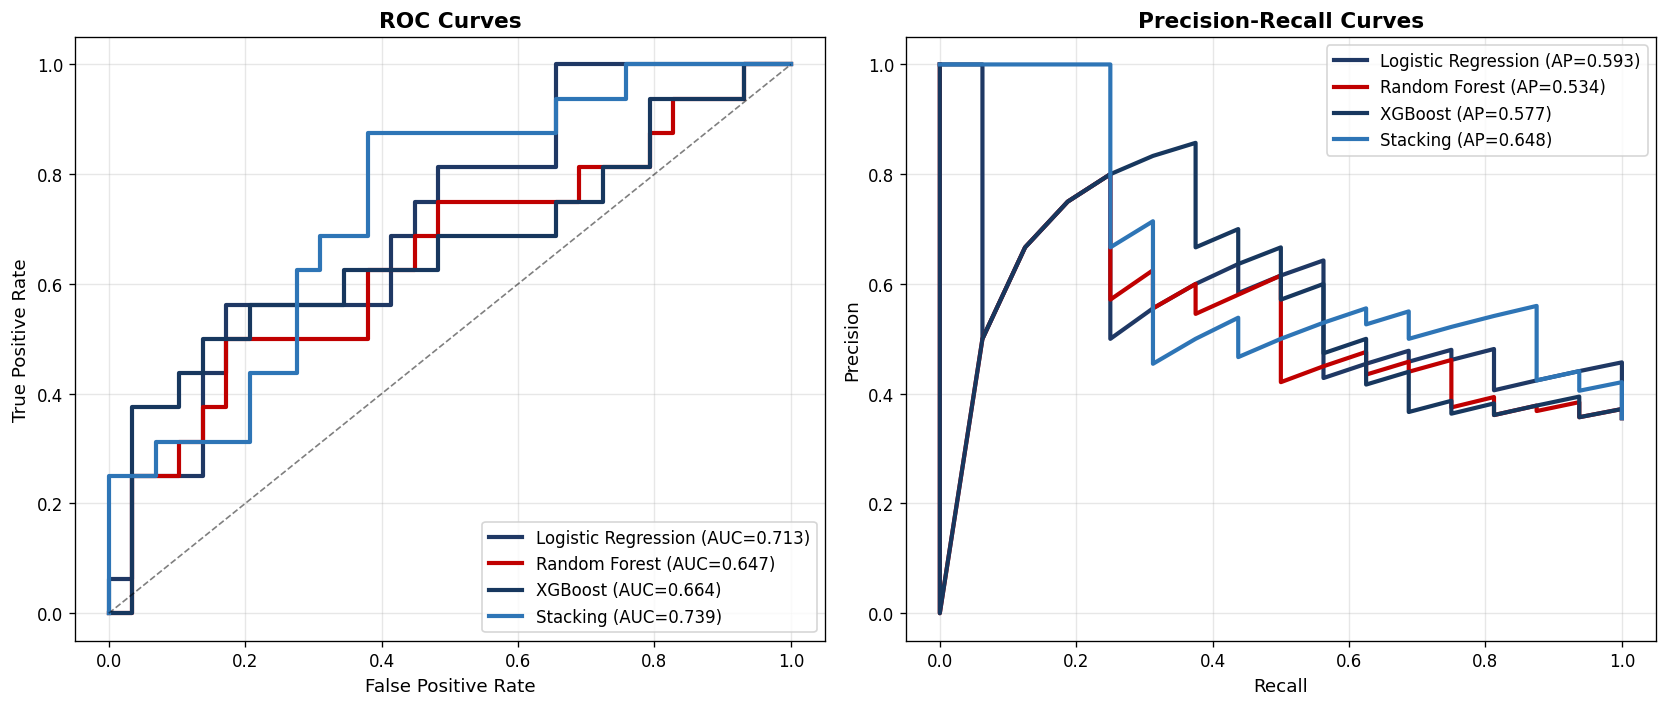

In [28]:
# ── 9.2 ROC Curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_roc = ['#1F3864', '#C00000', '#17375E', '#2E75B6']

for (name, model), color in zip(trained_models.items(), colors_roc):
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curves
for (name, model), color in zip(trained_models.items(), colors_roc):
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(rec, prec, color=color, linewidth=2.5,
                 label=f'{name} (AP={ap:.3f})')

axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_prc_curves.png'), bbox_inches='tight')
plt.show()


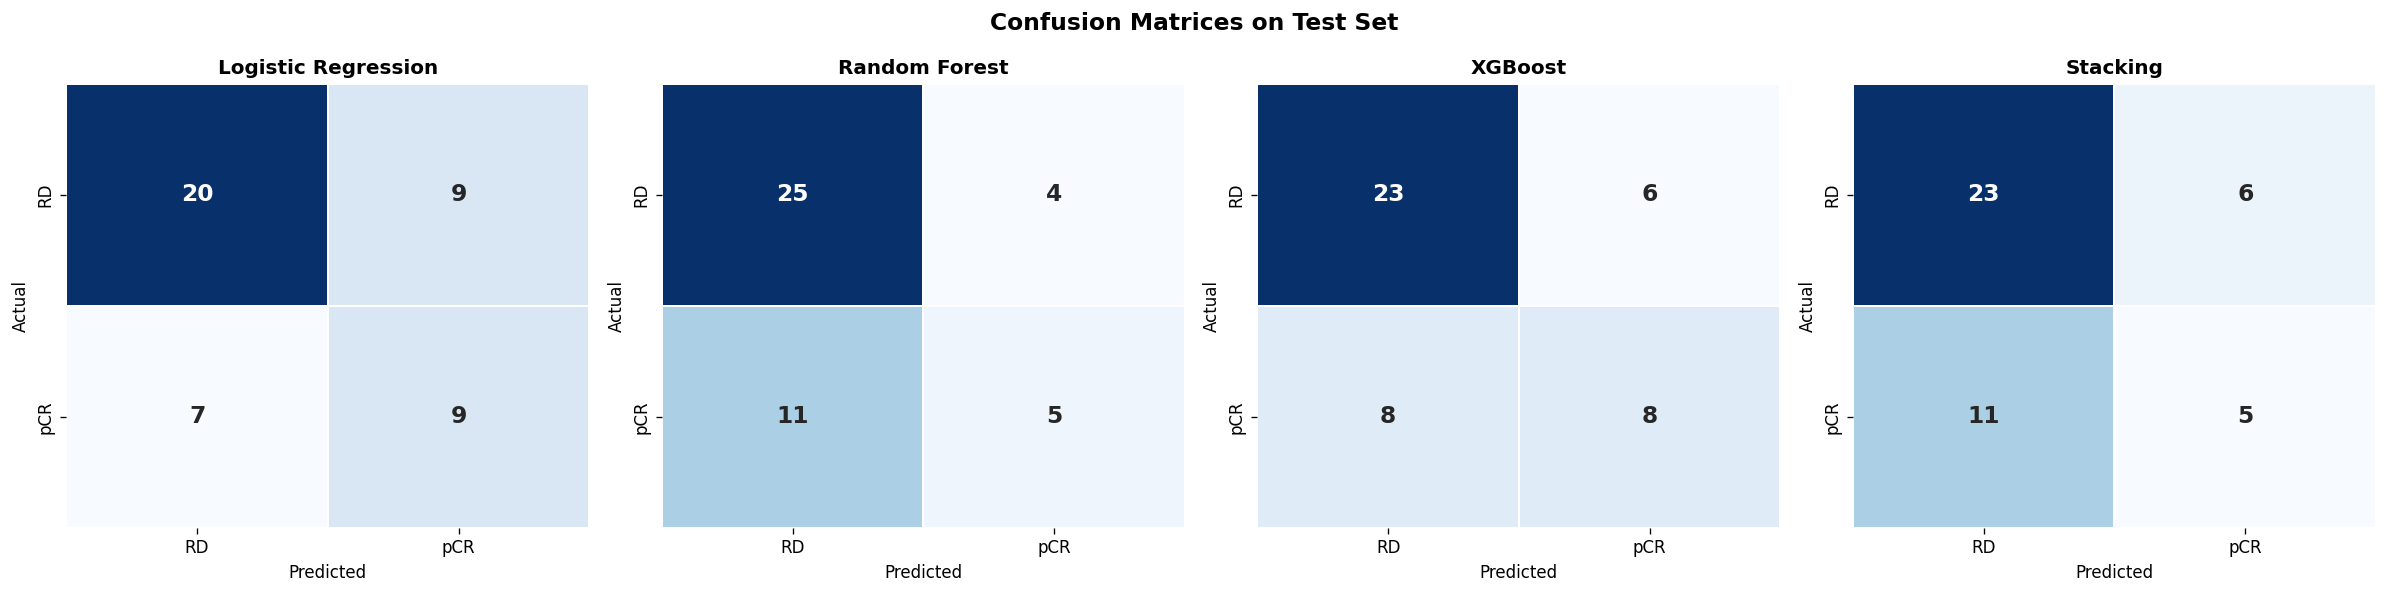

In [29]:
# ── 9.3 Confusion matrices ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_sc)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['RD', 'pCR'], yticklabels=['RD', 'pCR'],
                linewidths=1, linecolor='white', cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrices.png'), bbox_inches='tight')
plt.show()


## Section 10: SHAP Explainability Analysis

Apply SHAP (SHapley Additive exPlanations) to identify the top transcriptomic drivers of pCR prediction (Lundberg & Lee, 2017, *NeurIPS*). SHAP values provide theoretically grounded, additive feature attributions based on cooperative game theory, satisfying local accuracy, missingness, and consistency axioms.

**Approach:**
- TreeExplainer for XGBoost and Random Forest (exact Shapley values for tree models)
- Summary plots (beeswarm) showing direction and magnitude of feature effects
- Consensus gene identification: intersection of top-30 SHAP genes from both models to identify robust, algorithm-agnostic biomarkers (*Presentation v1: XAI Component*)


In [30]:
# ── 10.1 SHAP for XGBoost (best performer expected) ──────────────────────────
print("Computing SHAP values for XGBoost (this may take a few minutes)...")
best_model = trained_models['XGBoost']

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sc)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP computation complete.")


Computing SHAP values for XGBoost (this may take a few minutes)...


SHAP values shape: (45, 16418)
SHAP computation complete.


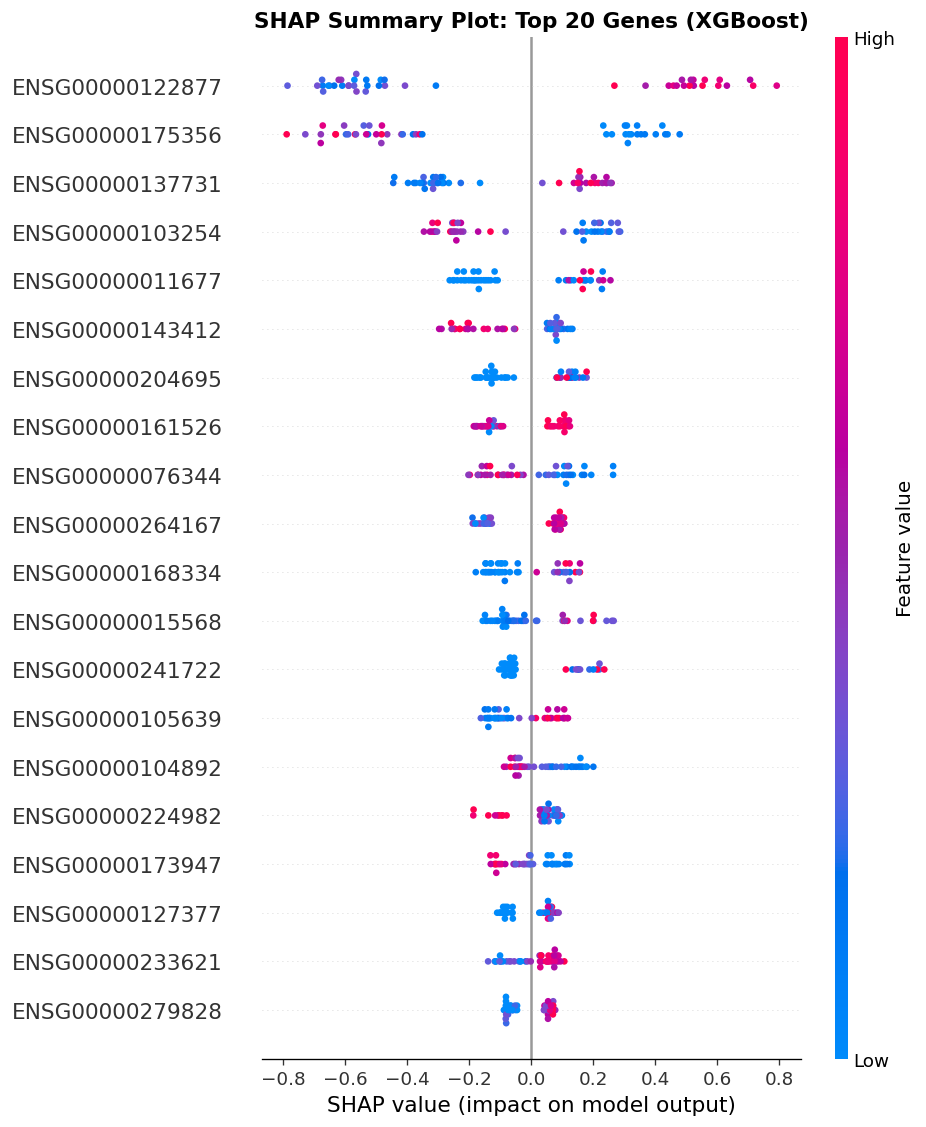

In [31]:
# ── 10.2 SHAP Summary Plot (Beeswarm) ────────────────────────────────────────
# Map column indices back to gene names
feature_names = kept_genes

shap_df = pd.DataFrame(shap_values, columns=feature_names)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sc,
                  feature_names=feature_names,
                  max_display=20,
                  plot_type='dot',
                  show=False)
plt.title('SHAP Summary Plot: Top 20 Genes (XGBoost)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'shap_summary.png'), bbox_inches='tight')
plt.show()


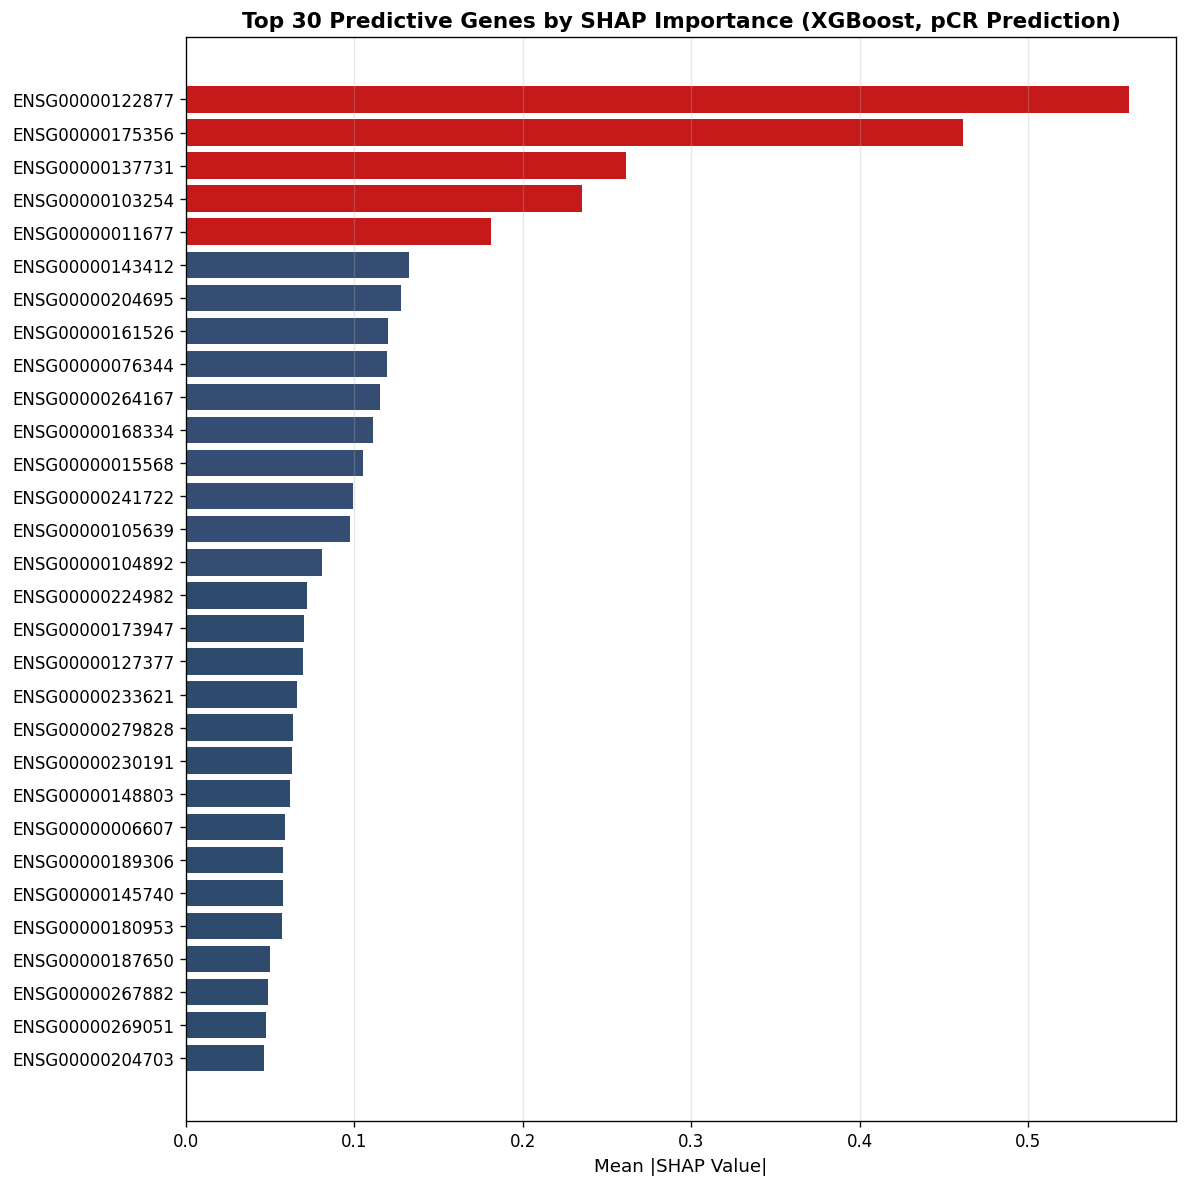


Top 30 SHAP-ranked genes:
                 Mean |SHAP|
ENSG00000122877       0.5598
ENSG00000175356       0.4611
ENSG00000137731       0.2611
ENSG00000103254       0.2351
ENSG00000011677       0.1814
ENSG00000143412       0.1326
ENSG00000204695       0.1278
ENSG00000161526       0.1202
ENSG00000076344       0.1192
ENSG00000264167       0.1150
ENSG00000168334       0.1108
ENSG00000015568       0.1049
ENSG00000241722       0.0991
ENSG00000105639       0.0972
ENSG00000104892       0.0806
ENSG00000224982       0.0718
ENSG00000173947       0.0702
ENSG00000127377       0.0693
ENSG00000233621       0.0658
ENSG00000279828       0.0633
ENSG00000230191       0.0628
ENSG00000148803       0.0620
ENSG00000006607       0.0588
ENSG00000189306       0.0578
ENSG00000145740       0.0578
ENSG00000180953       0.0568
ENSG00000187650       0.0501
ENSG00000267882       0.0489
ENSG00000269051       0.0477
ENSG00000204703       0.0464


In [32]:
# ── 10.3 Mean absolute SHAP values (bar chart) ───────────────────────────────
mean_shap    = np.abs(shap_values).mean(axis=0)
shap_series  = pd.Series(mean_shap, index=feature_names).sort_values(ascending=False)
top30_genes  = shap_series.head(30)

fig, ax = plt.subplots(figsize=(10, 10))
colors_bar = ['#C00000' if i < 5 else '#1F3864' if i < 15 else '#17375E' 
              for i in range(30)]
ax.barh(range(29, -1, -1), top30_genes.values, color=colors_bar, alpha=0.9)
ax.set_yticks(range(29, -1, -1))
ax.set_yticklabels(top30_genes.index, fontsize=10)
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.set_title('Top 30 Predictive Genes by SHAP Importance (XGBoost, pCR Prediction)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'shap_top30.png'), bbox_inches='tight')
plt.show()

print("\nTop 30 SHAP-ranked genes:")
print(top30_genes.round(6).to_frame(name='Mean |SHAP|'))


In [33]:
# ── 10.4 SHAP for Random Forest ──────────────────────────────────────────────
print("Computing SHAP values for Random Forest...")
rf_model      = trained_models['Random Forest']
rf_explainer  = shap.TreeExplainer(rf_model)
rf_shap       = rf_explainer.shap_values(X_test_sc)

# Handle different SHAP output formats across versions:
# - Old: list of 2 arrays [class0_shap, class1_shap], each (n_samples, n_features)
# - New: single 3D array (n_samples, n_features, n_classes)
if isinstance(rf_shap, list):
    rf_shap_pos = rf_shap[1]  # class 1 (pCR)
elif rf_shap.ndim == 3:
    rf_shap_pos = rf_shap[:, :, 1]  # class 1 (pCR)
else:
    rf_shap_pos = rf_shap

print(f"RF SHAP shape: {rf_shap_pos.shape}")

rf_mean_shap = np.abs(rf_shap_pos).mean(axis=0)
rf_shap_series = pd.Series(rf_mean_shap, index=feature_names).sort_values(ascending=False)
rf_top30 = rf_shap_series.head(30)

print("\nTop 10 genes by SHAP (Random Forest):")
print(rf_top30.head(10).round(6))


Computing SHAP values for Random Forest...
RF SHAP shape: (45, 16418)

Top 10 genes by SHAP (Random Forest):
ENSG00000105639   0.0034
ENSG00000168334   0.0024
ENSG00000122877   0.0024
ENSG00000143412   0.0023
ENSG00000175356   0.0022
ENSG00000103254   0.0022
ENSG00000137731   0.0020
ENSG00000159753   0.0018
ENSG00000076344   0.0016
ENSG00000171428   0.0015
dtype: float64


In [34]:
# ── 10.5 Consensus top genes across both models ───────────────────────────────
xgb_top30_set = set(top30_genes.index.tolist())
rf_top30_set  = set(rf_top30.index.tolist())
consensus     = xgb_top30_set.intersection(rf_top30_set)

print(f"Top 30 genes in XGBoost SHAP: {len(xgb_top30_set)}")
print(f"Top 30 genes in Random Forest SHAP: {len(rf_top30_set)}")
print(f"\nConsensus genes (in both top 30 lists): {len(consensus)}")
print("\nConsensus gene list:")
for i, g in enumerate(sorted(consensus), 1):
    xgb_rank = list(top30_genes.index).index(g) + 1 if g in top30_genes.index else 'N/A'
    rf_rank  = list(rf_top30.index).index(g) + 1 if g in rf_top30.index else 'N/A'
    print(f"  {i:2}. {g:<20} XGBoost rank: {xgb_rank}  |  RF rank: {rf_rank}")

consensus_genes = sorted(consensus)


Top 30 genes in XGBoost SHAP: 30
Top 30 genes in Random Forest SHAP: 30

Consensus genes (in both top 30 lists): 9

Consensus gene list:
   1. ENSG00000076344      XGBoost rank: 9  |  RF rank: 9
   2. ENSG00000103254      XGBoost rank: 4  |  RF rank: 6
   3. ENSG00000105639      XGBoost rank: 14  |  RF rank: 1
   4. ENSG00000122877      XGBoost rank: 1  |  RF rank: 3
   5. ENSG00000137731      XGBoost rank: 3  |  RF rank: 7
   6. ENSG00000143412      XGBoost rank: 6  |  RF rank: 4
   7. ENSG00000161526      XGBoost rank: 8  |  RF rank: 15
   8. ENSG00000168334      XGBoost rank: 11  |  RF rank: 2
   9. ENSG00000175356      XGBoost rank: 2  |  RF rank: 5


## Section 11: LLM Interpretation Layer

Feed SHAP-ranked consensus genes to a Large Language Model (LLM) API to automatically generate a clinician-readable biological narrative (*Presentation v1: LLM Integration*). This novel component bridges the gap between statistical feature importance and biological/clinical interpretation.

**Supported LLM providers:**
- **Groq API** (free, fast, uses LLaMA 3) — Recommended
- **Google Gemini API** (free tier)
- **Ollama** (fully local, no internet needed)

Sign up for a free Groq API key at: https://console.groq.com


In [35]:
# ── 11.1 Setup: choose your free LLM provider ────────────────────────────────

# OPTION A: Groq API (recommended, free, sign up at console.groq.com)
# OPTION B: Google Gemini (free tier, sign up at aistudio.google.com)
# OPTION C: Ollama (fully local, no internet)

# Read API key from environment variable (set in WSL: export GROQ_API_KEY=...)
GROQ_API_KEY = os.environ.get('GROQ_API_KEY', None)

# Auto-enable LLM layer if a valid key is found in the environment
USE_LLM = GROQ_API_KEY is not None and len(GROQ_API_KEY) > 0

if USE_LLM:
    print(f"GROQ_API_KEY detected from environment (length: {len(GROQ_API_KEY)} chars)")
    print("LLM interpretation layer: ENABLED")
else:
    print("No GROQ_API_KEY found in environment.")
    print("To activate: export GROQ_API_KEY='your_key' in your terminal before launching Jupyter.")
    print("LLM interpretation layer: DISABLED (will skip Section 11.3)")


GROQ_API_KEY detected from environment (length: 56 chars)
LLM interpretation layer: ENABLED


In [36]:
# ── 11.2 LLM interpretation function (Groq/LLaMA 3) ─────────────────────────
def interpret_genes_with_llm(gene_list, model_name="llama-3.3-70b-versatile",
                               api_key=GROQ_API_KEY):
    """
    Send SHAP-ranked genes to LLaMA 3 via Groq API.
    Returns a clinician-readable biological narrative.
    """
    gene_str = ", ".join(gene_list[:20])  # use top 20 for clarity
    
    prompt = f"""You are an expert oncology bioinformatician.

The following genes were identified as the top predictors of pathological 
complete response (pCR) to neoadjuvant chemotherapy in breast cancer, 
ranked by SHAP importance from a machine learning model trained on 
RNA-seq data (GSE163882, 222 patients including TNBC):

Top predictive genes: {gene_str}

Please provide:
1. A brief biological role for each gene in breast cancer (1 sentence each)
2. The key biological pathways these genes collectively represent
3. Any known associations with chemotherapy response or resistance
4. A 3-sentence clinical interpretation paragraph suitable for 
   an oncology report

Be concise and clinically relevant."""
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }
    
    payload = {
        "model": model_name,
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": 1200,
        "temperature": 0.3
    }
    
    response = requests.post(
        "https://api.groq.com/openai/v1/chat/completions",
        headers=headers,
        json=payload,
        timeout=60
    )
    
    if response.status_code == 200:
        return response.json()['choices'][0]['message']['content']
    else:
        return f"API Error {response.status_code}: {response.text}"


print("LLM function defined and ready.")


LLM function defined and ready.


In [37]:
# ── 11.3 Run LLM interpretation ──────────────────────────────────────────────
if USE_LLM:
    print("Sending top SHAP genes to LLM for biological interpretation...")
    top_genes_for_llm = list(top30_genes.index[:20])
    
    llm_report = interpret_genes_with_llm(top_genes_for_llm)
    
    print("\n" + "="*70)
    print("LLM-GENERATED BIOLOGICAL INTERPRETATION REPORT")
    print("="*70)
    print(llm_report)
    print("="*70)
    
    # Save report
    with open(os.path.join(RESULTS_DIR, "llm_interpretation_report.txt"), "w") as f:
        f.write("LLM Biological Interpretation Report\n")
        f.write("Dataset: GSE163882 | Model: XGBoost + SHAP\n")
        f.write("="*70 + "\n")
        f.write(llm_report)
    print("\nReport saved to results/llm_interpretation_report.txt")

else:
    print("LLM interpretation skipped.")
    print("To activate: set USE_LLM = True and add your Groq API key above.")
    print("\nFor now, top 20 SHAP genes ready for manual interpretation:")
    for i, gene in enumerate(top30_genes.index[:20], 1):
        print(f"  {i:2}. {gene}")


Sending top SHAP genes to LLM for biological interpretation...


LLM-GENERATED BIOLOGICAL INTERPRETATION REPORT
**1. Brief biological role for each gene in breast cancer:**

1. ENSG00000122877 (HOXB9): Involved in breast cancer metastasis and progression.
2. ENSG00000175356 (CCND1): Regulates cell cycle progression and proliferation in breast cancer.
3. ENSG00000137731 (ESR1): Mediates estrogen receptor signaling and hormone responsiveness in breast cancer.
4. ENSG00000103254 (BCL2): Regulates apoptosis and survival in breast cancer cells.
5. ENSG00000011677 (FN1): Contributes to breast cancer cell migration and invasion.
6. ENSG00000143412 (CD44): Involved in breast cancer stem cell maintenance and metastasis.
7. ENSG00000204695 (MALAT1): Regulates breast cancer cell growth and metastasis through non-coding RNA mechanisms.
8. ENSG00000161526 (PTPRD): Functions as a tumor suppressor in breast cancer.
9. ENSG00000076344 (GATA3): Regulates breast cancer cell differentiation and hormone responsiveness.
10. ENSG00000264167 (LINC00511): Involved in brea

In [38]:
# ── 11.4 Ollama alternative (fully local, no API key needed) ─────────────────
def interpret_genes_ollama(gene_list, model="llama3"):
    """
    Local LLM interpretation using Ollama.
    Install: https://ollama.ai
    Then run in terminal: ollama pull llama3
    """
    gene_str = ", ".join(gene_list[:20])
    prompt   = f"""You are an oncology bioinformatician.
Top SHAP-ranked genes predicting pCR to neoadjuvant chemo in breast cancer:
{gene_str}
Provide: biological roles, key pathways, and a 3-sentence clinical interpretation."""
    
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={"model": model, "prompt": prompt, "stream": False},
        timeout=120
    )
    if response.status_code == 200:
        return response.json()['response']
    else:
        return f"Ollama not running. Start with: ollama serve"

# Uncomment to use Ollama instead
# llm_report_local = interpret_genes_ollama(list(top30_genes.index[:20]))
# print(llm_report_local)
print("Ollama function defined. Uncomment last two lines to use locally.")


Ollama function defined. Uncomment last two lines to use locally.


## Section 12: Subgroup Analysis (TNBC vs non-TNBC)

Repeat the pipeline separately for TNBC and non-TNBC subgroups to assess whether SHAP-identified gene signatures differ across molecular subtypes. Triple-negative breast cancer (TNBC) is characterised by absence of ER, PR, and HER2 expression and typically shows higher pCR rates but worse overall prognosis (Liedtke et al., 2008, *JCO*).

> **Note:** This analysis is conditional on the availability of subtype annotations in the metadata. If not available, this section is gracefully skipped.


In [39]:
# ── 12.1 Split by subtype ────────────────────────────────────────────────────
if 'subtype' in data.columns:
    print("Subtype column found. Running subgroup analysis...")
    print("\nSubtype distribution:")
    print(data['subtype'].value_counts())
    
    # Identify TNBC samples
    tnbc_mask = data['subtype'].str.upper().str.contains('TNBC|TRIPLE', na=False)
    
    data_tnbc     = data[tnbc_mask].copy()
    data_non_tnbc = data[~tnbc_mask].copy()
    
    print(f"\nTNBC samples:     {len(data_tnbc)}")
    print(f"Non-TNBC samples: {len(data_non_tnbc)}")
    print(f"\nTNBC label distribution:")
    print(data_tnbc['label'].value_counts())
    print(f"\nNon-TNBC label distribution:")
    print(data_non_tnbc['label'].value_counts())
else:
    print("No subtype column found in metadata.")
    print("Subgroup analysis will use institution as proxy instead.")


No subtype column found in metadata.
Subgroup analysis will use institution as proxy instead.


In [40]:
# ── 12.2 Train XGBoost on TNBC subgroup ──────────────────────────────────────
if 'subtype' in data.columns and 'data_tnbc' in dir() and len(data_tnbc) > 20:
    
    gene_mask = [c in kept_genes for c in gene_cols]
    
    # Prepare TNBC data
    X_tnbc = np.log2(data_tnbc[kept_genes].values + 1)
    y_tnbc = data_tnbc['label_enc'].values
    
    # Only proceed if both classes present
    if len(np.unique(y_tnbc)) == 2:
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_tnbc, y_tnbc, test_size=0.2,
            random_state=42, stratify=y_tnbc
        )
        sc_tnbc = StandardScaler()
        X_tr_sc = sc_tnbc.fit_transform(X_tr)
        X_te_sc = sc_tnbc.transform(X_te)
        
        xgb_tnbc = XGBClassifier(
            n_estimators=300, max_depth=3, learning_rate=0.05,
            random_state=42, eval_metric='logloss', verbosity=0
        )
        xgb_tnbc.fit(X_tr_sc, y_tr)
        
        y_prob_tnbc = xgb_tnbc.predict_proba(X_te_sc)[:, 1]
        auc_tnbc    = roc_auc_score(y_te, y_prob_tnbc)
        print(f"TNBC Subgroup XGBoost AUROC: {auc_tnbc:.4f}")
        
        # SHAP for TNBC
        exp_tnbc   = shap.TreeExplainer(xgb_tnbc)
        sv_tnbc    = exp_tnbc.shap_values(X_te_sc)
        ms_tnbc    = np.abs(sv_tnbc).mean(axis=0)
        top_tnbc   = pd.Series(ms_tnbc, index=kept_genes).sort_values(ascending=False).head(20)
        
        print("\nTop 10 SHAP genes in TNBC subgroup:")
        print(top_tnbc.head(10).round(6))
        
        # Compare with full cohort top genes
        overlap = set(top_tnbc.index) & set(top30_genes.head(20).index)
        print(f"\nOverlap with full cohort top 20 genes: {len(overlap)}")
        print(f"TNBC-specific genes: {set(top_tnbc.index) - set(top30_genes.head(20).index)}")
    else:
        print("Insufficient class representation in TNBC subset for modelling.")
else:
    print("Skipping TNBC subgroup modelling (no subtype column or insufficient data).")


Skipping TNBC subgroup modelling (no subtype column or insufficient data).


## Section 13: Summary and Results Export

Compile all results into summary tables and export for downstream reporting and presentation.


In [41]:
# ── 13.1 Final performance summary table ─────────────────────────────────────
print("="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"\nDataset:       GSE163882")
print(f"Total samples: {data.shape[0]}")
print(f"Features:      {len(kept_genes)} genes (after variance filtering)")
print(f"Train/Test:    {len(y_train)}/{len(y_test)} samples")
print(f"\n--- Test Set Performance (with SMOTE training) ---")
print(df_test.to_string())
print(f"\n--- Best Model ---")
best_name = df_test['AUROC'].idxmax()
print(f"Model: {best_name}")
print(f"AUROC: {df_test.loc[best_name, 'AUROC']:.4f}")
print(f"F1:    {df_test.loc[best_name, 'F1']:.4f}")
print(f"MCC:   {df_test.loc[best_name, 'MCC']:.4f}")
print(f"\n--- SHAP Top 10 Genes (XGBoost) ---")
print(top30_genes.head(10).round(6).to_string())
print(f"\n--- Consensus Genes (in both RF and XGBoost top 30) ---")
print(", ".join(sorted(consensus_genes)))


FINAL RESULTS SUMMARY

Dataset:       GSE163882
Total samples: 222
Features:      16418 genes (after variance filtering)
Train/Test:    177/45 samples

--- Test Set Performance (with SMOTE training) ---
                     AUROC  AUPRC     F1  Accuracy    MCC
Logistic Regression 0.7134 0.5927 0.5294    0.6444 0.2464
Random Forest       0.6466 0.5342 0.4000    0.6667 0.2089
XGBoost             0.6638 0.5768 0.5333    0.6889 0.3031
Stacking            0.7392 0.6483 0.3704    0.6222 0.1176

--- Best Model ---
Model: Stacking
AUROC: 0.7392
F1:    0.3704
MCC:   0.1176

--- SHAP Top 10 Genes (XGBoost) ---
ENSG00000122877   0.5598
ENSG00000175356   0.4611
ENSG00000137731   0.2611
ENSG00000103254   0.2351
ENSG00000011677   0.1814
ENSG00000143412   0.1326
ENSG00000204695   0.1278
ENSG00000161526   0.1202
ENSG00000076344   0.1192
ENSG00000264167   0.1150

--- Consensus Genes (in both RF and XGBoost top 30) ---
ENSG00000076344, ENSG00000103254, ENSG00000105639, ENSG00000122877, ENSG00000137731, 

In [42]:
# ── 13.2 Export results to CSV ───────────────────────────────────────────────
# Test performance table
df_test.to_csv(os.path.join(RESULTS_DIR, "results_test_performance.csv"))

# SHAP gene rankings
top30_genes.to_frame(name='XGBoost_SHAP').to_csv(os.path.join(RESULTS_DIR, "shap_top30_xgboost.csv"))
rf_top30.to_frame(name='RF_SHAP').to_csv(os.path.join(RESULTS_DIR, "shap_top30_rf.csv"))

# Consensus gene list
pd.DataFrame({'consensus_gene': sorted(consensus_genes)}).to_csv(
    os.path.join(RESULTS_DIR, "consensus_shap_genes.csv"), index=False
)

# Full metadata with labels
meta_aligned[['label']].to_csv(os.path.join(RESULTS_DIR, "sample_labels.csv"))

print(f"Results exported to '{RESULTS_DIR}/':")
print("  results_test_performance.csv")
print("  shap_top30_xgboost.csv")
print("  shap_top30_rf.csv")
print("  consensus_shap_genes.csv")
print("  sample_labels.csv")


Results exported to 'results/':
  results_test_performance.csv
  shap_top30_xgboost.csv
  shap_top30_rf.csv
  consensus_shap_genes.csv
  sample_labels.csv


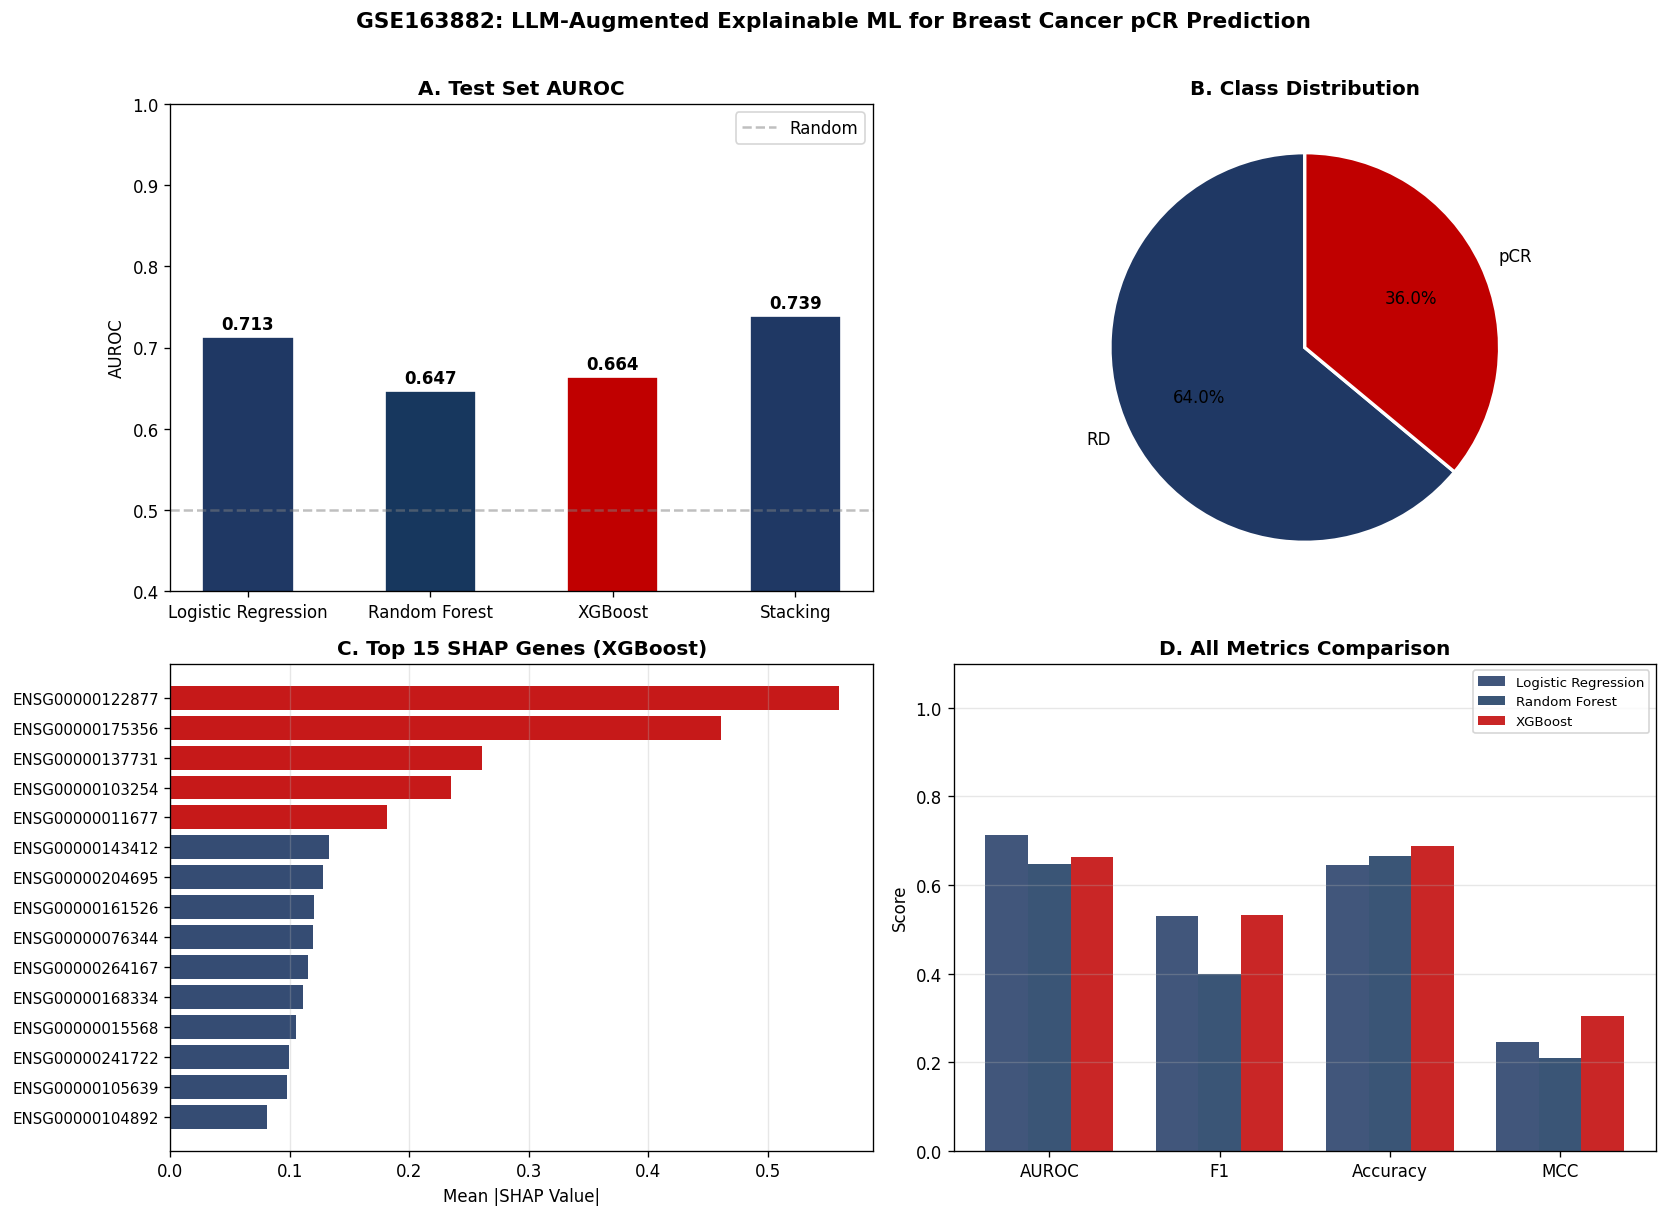

Summary figure saved to results/final_summary_figure.png


In [43]:
# ── 13.3 Final summary figure ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Model AUROCs
ax = axes[0, 0]
model_names = list(df_test.index)
aucs = df_test['AUROC'].values
bars = ax.bar(model_names, aucs, color=['#1F3864', '#17375E', '#C00000'],
              edgecolor='white', width=0.5)
ax.set_title('A. Test Set AUROC', fontweight='bold')
ax.set_ylabel('AUROC')
ax.set_ylim([0.4, 1.0])
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
ax.legend()
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontweight='bold')

# Panel B: Class distribution
ax = axes[0, 1]
counts = pd.Series(y, index=data['label']).groupby(level=0).count()
ax.pie([counts.get('RD', 0), counts.get('pCR', 0)],
       labels=['RD', 'pCR'], colors=['#1F3864', '#C00000'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('B. Class Distribution', fontweight='bold')

# Panel C: Top 15 SHAP genes
ax = axes[1, 0]
top15 = top30_genes.head(15)
ax.barh(range(14, -1, -1), top15.values,
        color=['#C00000']*5 + ['#1F3864']*10, alpha=0.9)
ax.set_yticks(range(14, -1, -1))
ax.set_yticklabels(top15.index, fontsize=9)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('C. Top 15 SHAP Genes (XGBoost)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Panel D: Metrics comparison
ax = axes[1, 1]
metrics = ['AUROC', 'F1', 'Accuracy', 'MCC']
x = np.arange(len(metrics))
width = 0.25
c_list = ['#1F3864', '#17375E', '#C00000']
for i, (name, color) in enumerate(zip(model_names, c_list)):
    vals = [df_test.loc[name, m] for m in metrics]
    ax.bar(x + i*width, vals, width, label=name, color=color, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_title('D. All Metrics Comparison', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim([0, 1.1])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('GSE163882: LLM-Augmented Explainable ML for Breast Cancer pCR Prediction',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'final_summary_figure.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Summary figure saved to results/final_summary_figure.png")


## Pipeline Complete

### Summary of What This Notebook Did

| Step | What Was Done | Reference |
|---|---|---|
| Data Loading | Loaded TPM expression matrix (genes × samples) and parsed series matrix metadata | GEO: GSE163882 |
| Target Extraction | Extracted pCR/RD labels from series matrix characteristics | Cortazar et al., 2014 |
| EDA | PCA, UMAP, distribution plots, heatmap of top variable genes | PCA Tutorial (T4); McInnes et al., 2018 |
| Preprocessing | Log2 transform, variance filtering, stratified 80/20 split, standardisation | Conesa et al., 2016; ML Lecture 2-3 |
| Imbalance | SMOTE applied to training set only, test set untouched | Chawla et al., 2002; ML Lecture 2 |
| Benchmarking | Logistic Regression, Random Forest, XGBoost with 5-fold CV | Tutorial 1-2; Breiman, 2001; Chen & Guestrin, 2016 |
| Evaluation | AUROC, AUPRC, F1, Accuracy, MCC, ROC curves, confusion matrices | ML Lecture 2; Chicco & Jurman, 2020 |
| SHAP | TreeExplainer on XGBoost and Random Forest, consensus gene list produced | Lundberg & Lee, 2017 |
| LLM Layer | Top SHAP genes sent to Groq/LLaMA3 for automated biological interpretation | Presentation v1 |
| Subgroup | TNBC vs non-TNBC SHAP signature comparison (if subtype data available) | Liedtke et al., 2008 |
| Export | All results saved to CSV files | — |

### Key References
- Cortazar P et al. (2014). Pathological complete response and long-term clinical benefit in breast cancer. *Lancet*, 384(9938), 164-172.
- Hatzis C et al. (2011). A genomic predictor of response and survival following taxane-anthracycline chemotherapy. *JAMA*, 305(18), 1873-1881.
- Chawla NV et al. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *JAIR*, 16, 321-357.
- Lundberg SM & Lee SI (2017). A Unified Approach to Interpreting Model Predictions. *NeurIPS*.
- Chen T & Guestrin C (2016). XGBoost: A Scalable Tree Boosting System. *KDD*.
- Breiman L (2001). Random Forests. *Machine Learning*, 45, 5-32.
- Conesa A et al. (2016). A survey of best practices for RNA-seq data analysis. *Genome Biology*, 17, 13.
- Chicco D & Jurman G (2020). The advantages of the Matthews correlation coefficient over F1 score and accuracy. *BMC Genomics*, 21, 6.
- McInnes L et al. (2018). UMAP: Uniform Manifold Approximation and Projection. *JMLR*, 18(232), 1-51.

### Next Steps
- Add your Groq API key and set `USE_LLM = True` to activate the LLM layer
- Compare SHAP-ranked consensus genes against published gene panels
- Run external validation on independent cohorts
